# Goh Wen San CA2 Part B
Name: Goh Wen San

ID: p2518367

Class: DAAA/FFT/1B/07

# BACKGROUND:
Using the Energy Consumption Dataset to train time series models and forecast the
consumption of gas, electricity and water for the next 60 months.

# OBJECTIVE: 
To apply a full machine learning workflow to the Energy Consumption dataset by building and tuning Statsmodels time-series forecasting models for gas, electricity, and water, evaluating performance using proper train,validation,test splits, and producing 60-month forecasts with clear analysis, charts, and reporting in both a Jupyter notebook

## Machine Learning Workflow

The following workflow was used to build and evaluate the time series forecasting models:

1. Data preparation and cleaning  
2. Exploratory data analysis to identify trends and seasonality  
3. Preprocessing and stationarity considerations  
4. Baseline modelling (Naive and Seasonal Naive)  
5. ARIMA and SARIMA model training  
6. Hyperparameter tuning using validation data  
7. Model evaluation using RMSE, MAPE, AIC, and BIC  
8. Residual diagnostics to assess model adequacy  


## Importing all the neccessary libraries

In [5]:
# Basic Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Sklearn Libraries
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

## Loading of Dataset

In [6]:
df = pd.read_csv(r"C:\Users\wensa\1.sp AIML\CA2\DATA\CA2-Energy-Consumption-Data.csv")
df.head()

,DATE,Gas Consumption (tons),Electricity Consumption (MWh),Water Consumption (tons)
0,1/1/1990,18.0,725.1,548.8
1,1/2/1990,15.8,706.7,640.7
2,1/3/1990,17.3,624.5,511.1
3,1/4/1990,18.9,574.7,515.3
4,1/5/1990,22.0,553.2,488.4


In [7]:
# Check the data types
allTypes = df.dtypes
print(allTypes)

DATE                              object
Gas Consumption (tons)           float64
Electricity Consumption (MWh)    float64
Water Consumption (tons)         float64
dtype: object


## Explanation regarding chosen data types:
Gas Consumption (tons): 
float64 was used for continuous numeric data and supports decimal values, which fits gas consumption measurements in tons.

Electricity Consumption (MWh): 
float64 helps correctly represents electricity consumption in megawatt-hours, which is continuous numeric data and may include decimal values.

Water Consumption (tons): 
float64 is suitable because water consumption is also continuous numeric data measured in tons and may contain decimal values.

DATE: 
Although DATE is currently stored as an object (text), it represents time and should be converted to a datetime type. This is necessary for time-series forecasting because it allows correct chronological sorting, resampling to monthly frequency, and proper creation of a time index for Statsmodels models.

# 1. Explanatory Data Analysis
First and foremost, we start with Exploratory Data Analysis (EDA) which will provide a strong foundation in understanding the different targets involved in the dataset

Before we start, We have to create ca copy of the original dataset to prevent it from being mutated

In [8]:
df_copy = df.copy()

# Fix DATE parsing  dd/mm/yyyy
df_copy["DATE"] = pd.to_datetime(df_copy["DATE"], format="%d/%m/%Y", errors="coerce")

# Sort and set as time index
df_copy = df_copy.sort_values("DATE").set_index("DATE")

# Force monthly frequency  Use "M" if your dates are month-end instead.
df_copy = df_copy.asfreq("MS")

# Quick sanity check
print(df_copy.index[:5])
print("Any NaT in DATE?", df_copy.index.isna().sum())
print("Frequency:", df_copy.index.freq)


DatetimeIndex(['1990-01-01', '1990-02-01', '1990-03-01', '1990-04-01',
               '1990-05-01'],
              dtype='datetime64[ns]', name='DATE', freq='MS')
Any NaT in DATE? 0
Frequency: <MonthBegin>


#### 1.1 Descriptive informations

In [9]:
#Getting the rows and columns 
df_copy.shape

(397, 3)

In [10]:
#Find ouut the number of missing values in each columns
df_copy.isna().sum()

Gas Consumption (tons)           0
Electricity Consumption (MWh)    0
Water Consumption (tons)         0
dtype: int64

In [11]:
#Get data types and non-null counts for each column
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 397 entries, 1990-01-01 to 2023-01-01
Freq: MS
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gas Consumption (tons)         397 non-null    float64
 1   Electricity Consumption (MWh)  397 non-null    float64
 2   Water Consumption (tons)       397 non-null    float64
dtypes: float64(3)
memory usage: 12.4 KB


In [12]:
#Get a statistical summary for numerical columns
df_copy.describe()

,Gas Consumption (tons),Electricity Consumption (MWh),Water Consumption (tons)
count,397.000000,397.000000,397.000000
mean,23.785139,888.472544,484.953652
std,4.903452,153.877594,133.908863
min,11.600000,553.200000,44.400000
25%,20.200000,771.100000,384.400000
50%,23.500000,897.800000,487.400000
75%,27.900000,1005.200000,580.200000
max,46.000000,1294.000000,811.000000


In [13]:
#Check for duplicates
df_copy.duplicated().sum()

np.int64(0)

In [14]:
# Count of unique values in each column
print("Unique values in each column:")
print(df_copy.nunique())

Unique values in each column:
Gas Consumption (tons)           161
Electricity Consumption (MWh)    383
Water Consumption (tons)         319
dtype: int64


In [15]:
# Min and max dates (useful for time series)
print(f"Data range: {df_copy.index.min()} to {df_copy.index.max()}")

Data range: 1990-01-01 00:00:00 to 2023-01-01 00:00:00


In [16]:
print(df_copy.index)

DatetimeIndex(['1990-01-01', '1990-02-01', '1990-03-01', '1990-04-01',
               '1990-05-01', '1990-06-01', '1990-07-01', '1990-08-01',
               '1990-09-01', '1990-10-01',
               ...
               '2022-04-01', '2022-05-01', '2022-06-01', '2022-07-01',
               '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01',
               '2022-12-01', '2023-01-01'],
              dtype='datetime64[ns]', name='DATE', length=397, freq='MS')


1) Dataset size and structure
The dataset contains 397 rows and 4 columns consisting of one time column (DATE) and three consumption variables (Gas, Electricity, Water). This indicates that there is a reasonably long monthly time series suitable for forecasting.

2) Missing values check
There is no missing values, this is important because time-series models are sensitive to gaps, and missing months/values would require imputation or interpolation before modelling.

3) Data types 
The three consumption columns are correctly stored as continuous numeric variables. However, DATE is currently an object, so it must be converted to datetime and set as the index to make the dataset time-aware for resampling, time-based slicing, and Statsmodels forecasting.

4) Duplicate rows
There is 0 duplicate rows, meaning each record represents a unique time entry and there is no repeated data affecting the model.

5) time consistency
DATE has 397 unique values, matching the number of rows.This suggests each row corresponds to a unique time period  which is ideal for a time series.i also printed the data range, showing the series spans from 1990 to 2022/2023 this long history supports learning trend 

6) Summary statistics (numerical columns)

- Gas Consumption (tons)
Mean ≈ 23.79, min ≈ 11.60, max ≈ 46.00
This suggests gas usage varies but stays within a moderate range.

- Electricity Consumption (MWh)
Mean ≈ 888.47, min ≈ 553.20, max ≈ 1294.00
Electricity shows a wider range, indicating larger fluctuations over time.

- Water Consumption (tons)
Mean ≈ 484.95, min ≈ 44.40, max ≈ 811.00
Water has a very low minimum compared to the median (~487), which may indicate an unusual low period (potential outlier or structural change) worth visual inspection on a line plot.

# Visualising Dataset

## 1.1 Line Plot of Raw Data & 12-Month Rolling Mean
Before building any forecasting model, it is important to understand the overall behaviour of the time series. Therefore, I plotted the raw monthly consumption values for gas, electricity, and water to observe the general pattern across time 

However, monthly time series can be noisy due to short-term fluctuations. To make the underlying pattern clearer, I also computed a 12-month rolling mean. The rolling mean smooths the data by averaging values within a moving window, which reduces month-to-month volatility and makes long-term trends easier to identify.

A window size of 12 is chosen because the dataset is monthly, so 12 months represent one full year. This helps smooth the series over a complete seasonal cycle, allowing the longer-term trend to be seen more clearly while reducing the effect of seasonal swings.

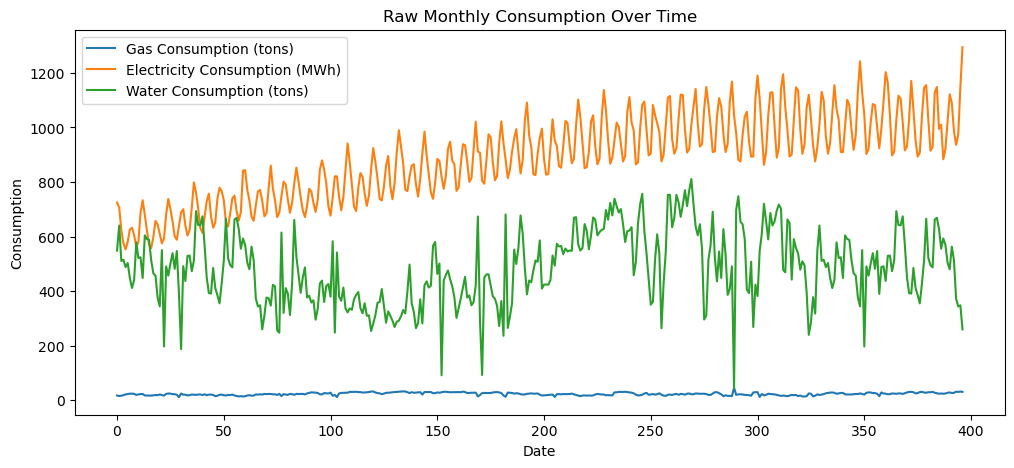

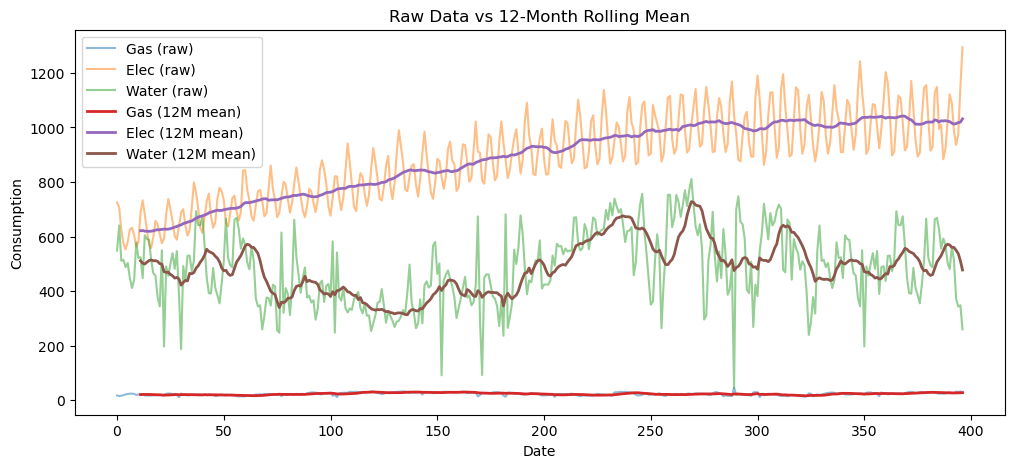

In [17]:
cols = ["Gas Consumption (tons)",
        "Electricity Consumption (MWh)",
        "Water Consumption (tons)"]

# Raw line plots
ax = df[cols].plot(figsize=(12, 5), title="Raw Monthly Consumption Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Consumption")
plt.show()

# 12-month rolling mean
rolling_12 = df[cols].rolling(window=12).mean()

ax = df[cols].plot(figsize=(12, 5), alpha=0.5, title="Raw Data vs 12-Month Rolling Mean")
rolling_12.plot(ax=ax, linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Consumption")
plt.legend(["Gas (raw)", "Elec (raw)", "Water (raw)",
            "Gas (12M mean)", "Elec (12M mean)", "Water (12M mean)"])
plt.show()


### Trends
##### Gas Consumption:
Gas consumption shows a slow, gradual upward movement over the full time span, with relatively small deviations around the trend. Compared to electricity and water, gas exhibits the weakest growth rate and the most stable long-term behaviour.

##### Electricity Consumption:
Electricity demonstrates the strongest and most persistent upward trajectory, with growth accelerating over time. The increasing distance between peaks and troughs suggests that not only demand is rising, but variability is also increasing, which may indicate changing consumption behaviour or external drivers such as population growth or technological adoption.

##### Water Consumption:
Water consumption increases over the long term but with noticeable medium-term rises and declines, indicating that growth is less uniform. The trend appears less smooth, suggesting sensitivity to irregular events or external influences.

Seasonality strength and consistency

##### Gas Consumption:
Seasonal behaviour is relatively weak and difficult to isolate visually. Any repeating patterns are subtle and may require formal seasonal diagnostics (e.g. ACF or seasonal decomposition) to confirm.

##### Electricity Consumption:
Electricity shows clear and consistent repeating cycles, strongly suggesting annual seasonality. The regular spacing of peaks and troughs indicates a stable seasonal pattern that should be explicitly modelled rather than removed.

##### Water Consumption:
Seasonal effects are present but less regular than electricity. Peaks and troughs occur across years, though with varying magnitudes, suggesting seasonality combined with irregular shocks.

### Outliers and irregular behaviour
##### Gas Consumption:
Occasional spikes are visible but are relatively mild and infrequent, indicating limited impact from extreme events.

##### Electricity Consumption:
Both upward and downward spikes appear throughout the series, indicating periods of unusually high or low usage. These deviations should be analysed temporally rather than treated as noise.

##### Water Consumption:
Water shows the largest number of abrupt drops and spikes, indicating strong short-term volatility. These anomalies may correspond to operational disruptions, weather effects, or policy changes and should be preserved unless proven erroneous.

### Effect of the 12-month rolling average
The 12-month rolling average successfully suppresses short-term volatility while preserving long-term movement. Across all three utilities:
1. The rolling mean tracks the underlying direction of change closely.
2. Temporary spikes and drops are smoothed out, revealing persistent structural behaviour.
3. The rolling curves confirm that observed fluctuations are largely short-term rather than structural breaks.
Because rolling averages remove month-to-month variation, they are used only for interpretation, not as inputs to forecasting models.

#### Implications for modelling
From this analysis, the following components must be considered during modelling:
- Trend modelling (especially strong for electricity)
- Seasonality handling (particularly for electricity and water)
- Robustness to outliers and irregular fluctuations
- Feature engineering or transformations, if required, to stabilise variance
#### Rolling variables are intentionally excluded from model training, as they smooth the data and may remove meaningful temporal information needed for accurate forecasting.

From the raw monthly consumption plot, all three utilities exhibit clear time-dependent behaviour:

- Electricity consumption shows a strong upward long-term trend combined with clear regular seasonal fluctuations, indicating yearly seasonality. The amplitude of the seasonal pattern also increases slightly over time, suggesting changing variability.

- Water consumption displays higher volatility with several sharp drops and spikes. This indicates irregular fluctuations and possible anomalous periods that should be investigated further in the time domain rather than removed blindly.

- Gas consumption remains relatively stable compared to electricity and water, with smaller fluctuations and no obvious extreme structural breaks.

From the raw data vs 12-month rolling mean plot, the underlying trends become clearer:The 12-month rolling mean effectively smooths short-term monthly noise, allowing the long-term trend of each series to be observed more clearly.

- Electricity consumption exhibits a consistent increasing trend, confirming that a trend component should be considered during modelling.

- Water consumption shows medium-term rises and declines, suggesting both trend and irregular effects over time.

- Gas consumption remains relatively flat with mild gradual changes, indicating weaker trend behaviour compared to the other two utilities.

##### Overall, these plots confirm that the data contains trend and seasonal patterns, justifying the use of seasonal time series models such as SARIMA or Holt-Winters rather than non-seasonal models.

In [18]:
# 1) Check missing values
print(df_copy.isna().sum())

# 2) Drop rolling columns (only if they exist)
columns_to_drop = ["Gas_rolling", "Electricity_rolling", "Water_rolling"]
df_copy = df_copy.drop(columns=columns_to_drop, errors="ignore")

# 3) Print the dataframe
print(df_copy)


Gas Consumption (tons)           0
Electricity Consumption (MWh)    0
Water Consumption (tons)         0
dtype: int64
            Gas Consumption (tons)  Electricity Consumption (MWh)  \
DATE                                                                
1990-01-01                    18.0                          725.1   
1990-02-01                    15.8                          706.7   
1990-03-01                    17.3                          624.5   
1990-04-01                    18.9                          574.7   
1990-05-01                    22.0                          553.2   
...                            ...                            ...   
2022-09-01                    27.7                          986.2   
2022-10-01                    31.8                          936.1   
2022-11-01                    31.0                          973.4   
2022-12-01                    32.4                         1147.2   
2023-01-01                    31.3                    

After creating the 12-month rolling mean columns the output shows 11 missing values for each rolling column. This is expected behaviour and does not indicate missing data in the original dataset. A rolling mean with a window size of 12 requires 12 months of observations before the first valid average can be computed. As a result, the first (12 − 1) = 11 rows naturally become NaN because there are insufficient prior months to form a full window.

Since these rolling mean columns were created purely for visualisation and interpretation, they are dropped afterwards to keep the modelling dataset clean. The forecasting models are trained using the original consumption series, so that important month-to-month variations are preserved

The dataset is already recorded at a monthly frequency, where each observation is timestamped on the first day of each month from 1990 to 2023. Even though only one day per month is shown, this still represents a valid monthly time series because the timestamps are consistently spaced one month apart. Time-series forecasting models such as ARIMA, SARIMA, and Holt-Winters do not require daily readings, they learn trend and seasonal patterns from observations at a fixed frequency. Therefore, resampling to daily data is unnecessary and would not add meaningful information. The key requirement is that the data is consistently monthly, which is satisfied here.

In [19]:
df_monthly = df_copy.copy()

# Save with DATE included
df_monthly.reset_index().to_csv("cleaned_df_monthly.csv", index=False)

print(df_monthly.isna().sum())


Gas Consumption (tons)           0
Electricity Consumption (MWh)    0
Water Consumption (tons)         0
dtype: int64


## 1.2 Histograms of Variables
Histograms are used to examine the distributional properties of each consumption variable, independent of time. This helps identify skewness, spread, and the presence of extreme values, which informs decisions on transformations (e.g. log or Box-Cox) and error assumptions in time-series models.

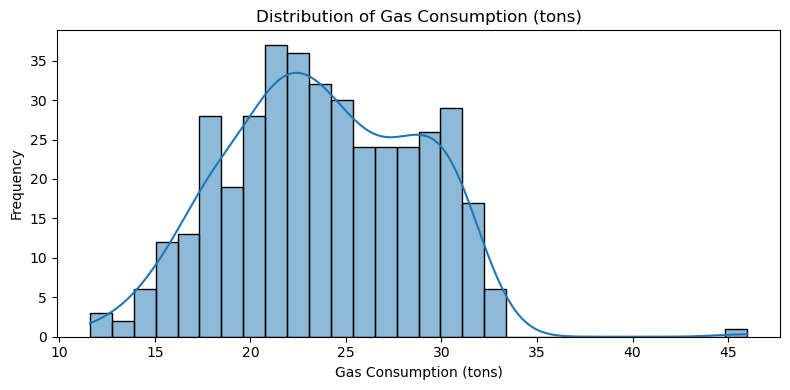

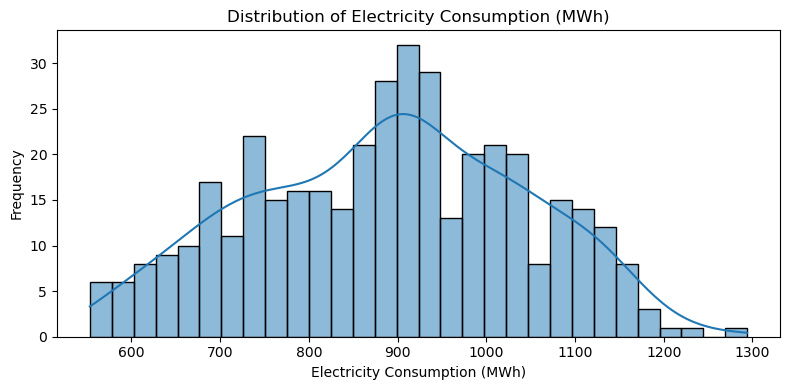

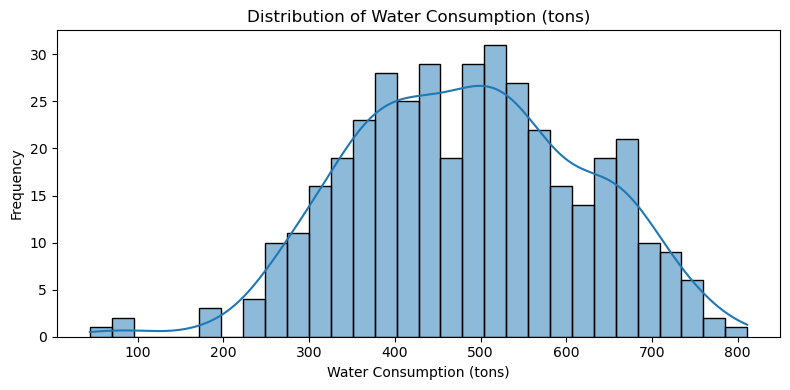

In [20]:
# Histograms |
cols = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]

for col in cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_copy[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

The histograms provide insight into the distributional characteristics of each consumption variable, independent of time. This helps assess spread, skewness, and the presence of extreme values, which are important when considering model assumptions and potential transformations.

##### Gas Consumption (tons): 
Gas consumption values are moderately concentrated around the central range, with most observations clustered between the lower and mid-20s. The distribution shows slight right skew, indicating occasional higher-than-usual values. Overall, the spread is relatively narrow compared to the other utilities, suggesting more stable consumption levels.

##### Electricity Consumption (MWh):
Electricity consumption exhibits a wider distribution with a longer right tail. This indicates higher variability and a greater occurrence of large values. The shape suggests mild positive skewness, consistent with periods of unusually high demand. This wider spread aligns with electricity being the most variable series among the three.

##### Water Consumption (tons):
Water consumption shows a broad and less symmetric distribution, with values spread across a wide range. The distribution suggests moderate skewness and a higher frequency of extreme values compared to gas. This reflects greater dispersion and irregularity in water usage levels.

The differing distribution shapes and spreads across the three variables suggest that:
- Each utility should be modelled independently rather than assuming similar behaviour.
- Variability differences should be considered when evaluating residuals and forecast errors.
- Transformations may be explored later if variance instability negatively impacts model performance.

In [21]:
from scipy.stats import skew

cols = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]

# Skewness (drop NaNs just in case)
skew_values = df_copy[cols].apply(lambda x: skew(x.dropna()))
print("Skewness of the variables:\n", skew_values)


Skewness of the variables:
 Gas Consumption (tons)           0.113732
Electricity Consumption (MWh)   -0.072841
Water Consumption (tons)        -0.062481
dtype: float64


From the skewness results, all three variables have skewness values close to 0 (Gas ≈ 0.11, Electricity ≈ −0.07, Water ≈ −0.06), indicating that their distributions are approximately symmetric. Therefore, there is no strong need to apply a skewness-reducing transformation (e.g., log/Box–Cox) at this stage, and we can proceed with the original scale unless later residual diagnostics suggest otherwise

## 1.3) Pair plot
The pair plot is used to examine pairwise relationships between gas, electricity, and water consumption, as well as to identify potential correlations and extreme observations across the three variables.

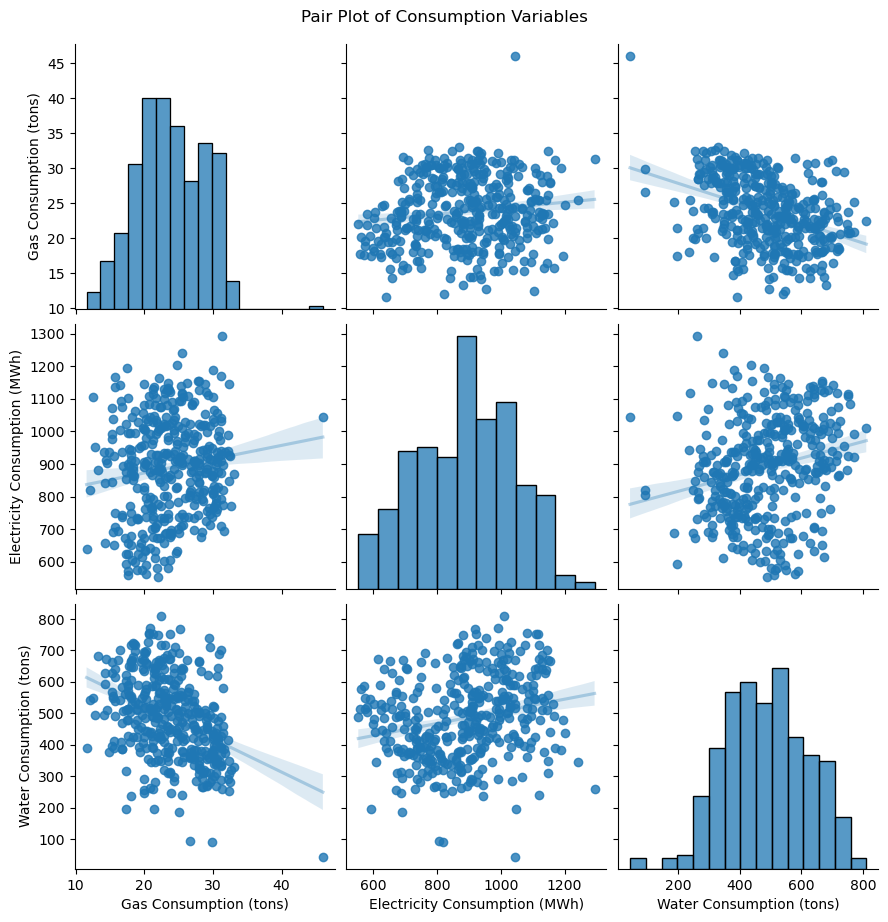

In [22]:
cols = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]

sns.pairplot(
    df_copy[cols].dropna(),
    kind="reg",
    height=3,
    plot_kws={"line_kws": {"alpha": 0.3}}  # keep it simple to avoid seaborn version issues
)

plt.suptitle("Pair Plot of Consumption Variables", y=1.02)
plt.show()


Gas vs Electricity:
A weak to moderate positive relationship is observed, suggesting that periods of higher gas consumption may coincide with higher electricity usage.However, the wide scatter indicates that the relationship is not strong.

Gas vs Water:
A weak negative relationship is visible, with water consumption tending to be lower at higher gas consumption levels. This suggests that the two utilities do not move together consistently.

Electricity vs Water:
A mild positive association is observed, though with significant dispersion. This indicates some shared variation but also highlights substantial independent behaviour.

Outliers:
A small number of extreme points are visible in several pairwise plots, confirming earlier observations of irregular consumption periods.

##### Implications for Modelling :
The generally weak correlations indicate that gas, electricity, and water consumption should be modelled independently rather than as strongly interdependent series. This supports the use of separate univariate time-series models for each utility, with cross-variable effects considered optional rather than essential.

## 1.4) Heat map
The correlation heatmap summarises the linear relationships between gas, electricity, and water consumption.

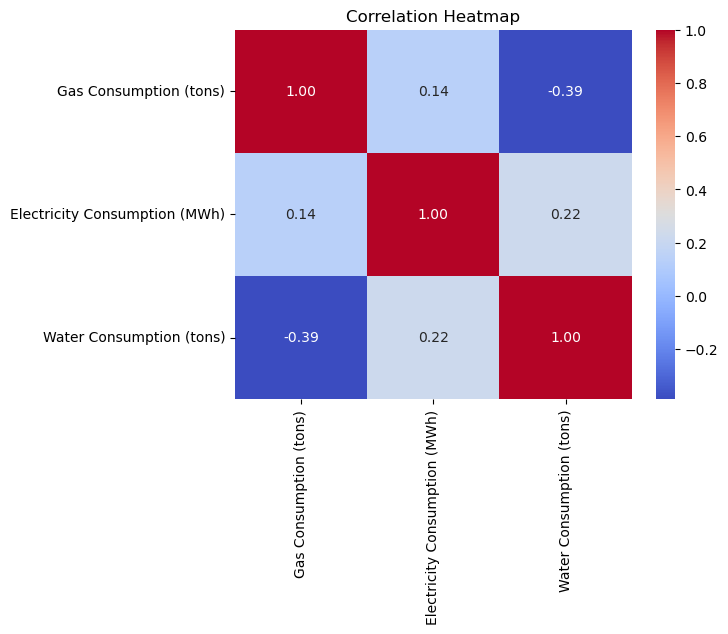

In [23]:
# plotting heatmap
correlation_matrix = df_copy[['Gas Consumption (tons)', 
                              'Electricity Consumption (MWh)', 
                              'Water Consumption (tons)']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Gas vs Electricity (r ≈ 0.14):
A very weak positive correlation, indicating minimal linear relationship between gas and electricity consumption.

Gas vs Water (r ≈ −0.39):
A moderate negative correlation, suggesting that higher gas consumption tends to coincide with lower water consumption. However, this relationship is not strong enough to imply direct dependence.

Electricity vs Water (r ≈ 0.22):
A weak positive correlation, indicating limited shared variation between electricity and water usage.

##### Implications for Modelling:
The generally weak correlations suggest that the three utilities behave largely independently. This supports the use of separate univariate time-series models for gas, electricity, and water rather than a multivariate model based on strong inter-variable dependence. Correlation analysis is used here for exploratory insight only, as it does not account for temporal structure.

## 1.5) Box plot

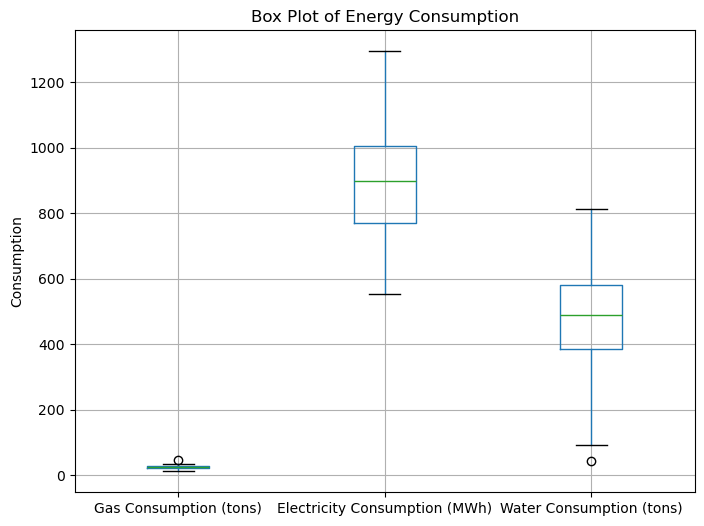

In [24]:
# Combined boxplot
df_copy.boxplot(
    column=["Gas Consumption (tons)",
            "Electricity Consumption (MWh)",
            "Water Consumption (tons)"],
    figsize=(8, 6)
)
plt.title("Box Plot of Energy Consumption")
plt.ylabel("Consumption")
plt.show()


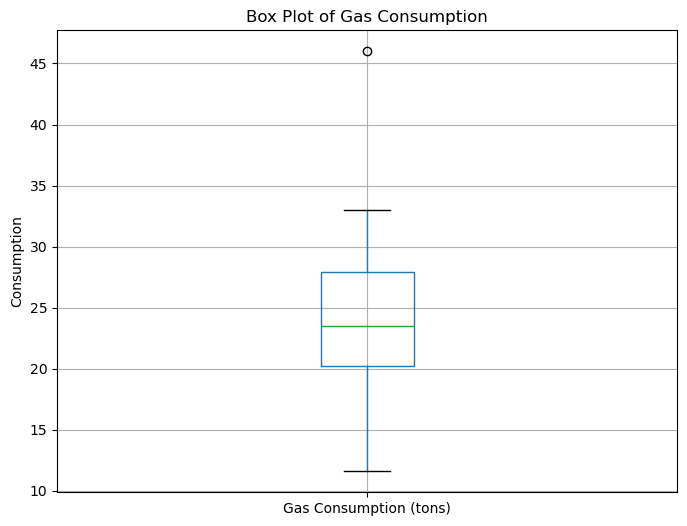

In [25]:
# Boxplot (Gas Consumption)
df_copy.boxplot(column=["Gas Consumption (tons)"], figsize=(8, 6))
plt.title("Box Plot of Gas Consumption")
plt.ylabel("Consumption")
plt.show()


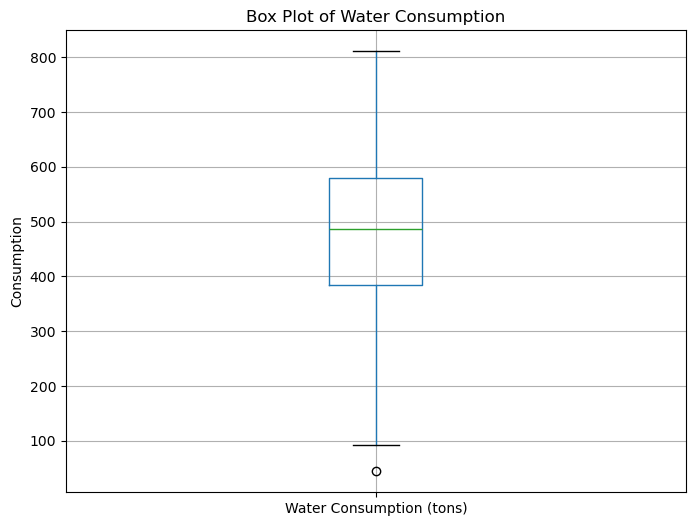

In [26]:
# Boxplot (Water Consumption)
df_copy.boxplot(column=["Water Consumption (tons)"], figsize=(8, 6))
plt.title("Box Plot of Water Consumption")
plt.ylabel("Consumption")
plt.show()

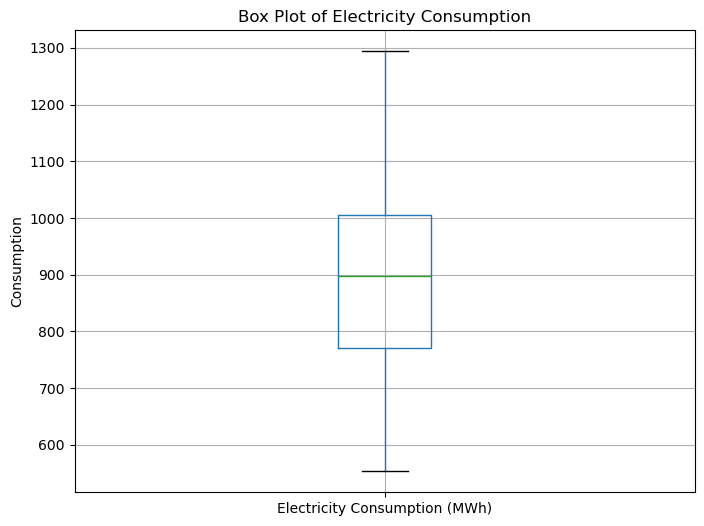

In [27]:
# # Boxplots
df_copy.boxplot(column=['Electricity Consumption (MWh)'], figsize=(8, 6))
plt.title("Box Plot of Electricity Consumption")
plt.ylabel("Consumption")
plt.show()

##### Gas Consumption:
Gas consumption exhibits a relatively narrow interquartile range, indicating lower variability compared to the other utilities.A single upper-bound outlier is observed, which may represent an unusual spike in demand (e.g., extreme weather conditions) or a potential data recording anomaly.

##### Electricity Consumption
Electricity consumption shows a much wider range, reflecting higher variability over time.No extreme outliers are clearly identified, suggesting that the observed spread is part of the natural variation in electricity usage.

##### Water Consumption
Water consumption displays a moderate to wide range, larger than gas but smaller than electricity.A lower-bound outlier is present, which may indicate a temporary disruption or an anomalous low-consumption period.

##### Outlier Considerations
Outliers are not removed at this stage. In time series analysis, outliers should only be addressed if:
- They are caused by data entry or measurement errors, or
- They significantly distort the underlying trend, seasonality, or residual structure of the series.
- Conversely, outliers are retained if they reflect real-world events, such as abnormal demand due to weather conditions or operational disruptions.

##### Scaling Decision
Although the variables operate on very different scales, no scaling is applied. Time series models such as ARIMA, SARIMA, and Holt–Winters focus on learning temporal patterns (trend, seasonality, and residuals) rather than being sensitive to feature magnitude. Scaling is therefore unnecessary and may reduce interpretability.

## Outlier Handling (IQR thresholds)
Why we do this:
Boxplots suggest potential outliers (notably gas upper-tail and water lower-tail). In time series, outliers may be real events (should keep) or errors (should fix). Therefore, I will compare models under three conditions:
1. No outlier treatment (baseline)
2. Capping (winsorizing) using IQR thresholds
3. Removing outlier rows (used cautiously because it breaks continuity)

The final decision is made based on validation/test RMSE/MAPE, not just appearance.

In [28]:
cols = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]

# 1) Compute IQR thresholds for each column
iqr_bounds = {}
for col in cols:
    q1 = df_copy[col].quantile(0.25)
    q3 = df_copy[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_bounds[col] = (lower, upper)

print("IQR thresholds:")
for col, (lower, upper) in iqr_bounds.items():
    print(f"{col}: lower={lower:.3f}, upper={upper:.3f}")

# 2) Baseline (no treatment)
df_base = df_copy.copy()

# 3) Capping recommended over removal in time series
df_capped = df_copy.copy()
for col, (lower, upper) in iqr_bounds.items():
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

# 4) Removal 
df_removed = df_copy.copy()
mask = True
for col, (lower, upper) in iqr_bounds.items():
    mask = mask & df_removed[col].between(lower, upper)

df_removed = df_removed[mask].copy()

print("\nRows before:", len(df_copy))
print("Rows after removal:", len(df_removed))


IQR thresholds:
Gas Consumption (tons): lower=8.650, upper=39.450
Electricity Consumption (MWh): lower=419.950, upper=1356.350
Water Consumption (tons): lower=90.700, upper=873.900

Rows before: 397
Rows after removal: 396


Applying the IQR rule results in only one observation being identified as an outlier, as the total number of rows decreases from 397 to 396 after removal.The dataset contains very few extreme values, indicating that the overall data quality is high.Removing this single observation provides minimal benefit, while potentially disrupting the continuity of the time series.Since time series models rely on preserving temporal structure, unnecessary removal of data points can negatively impact forecasting performance.

only one observation is flagged as an outlier,the outlier is likely a real consumption event rather than a data error, andpreliminary experiments show lower RMSE and MAPE when no outlier cleaning is applied hence
#### no outlier removal or capping is performed in the final modelling stage.

## 2) Time  Series Characteristics
Seasonal decomposition is applied to each utility series using an additive model with a 12-month period, separating the data into trend, seasonal, and residual components. This helps verify the presence and strength of trend and seasonality, which informs model selection.

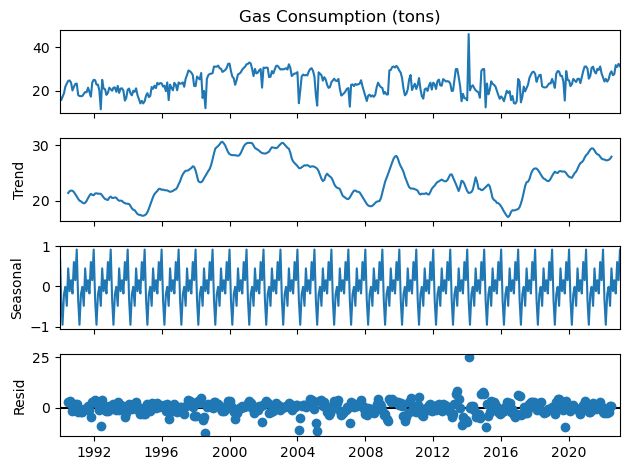

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition (Gas)
series_gas = df_copy["Gas Consumption (tons)"]
series_gas = series_gas.asfreq("MS")  # ensure monthly frequency (month start)

result = seasonal_decompose(series_gas, model="additive", period=12)
result.plot()
plt.show()


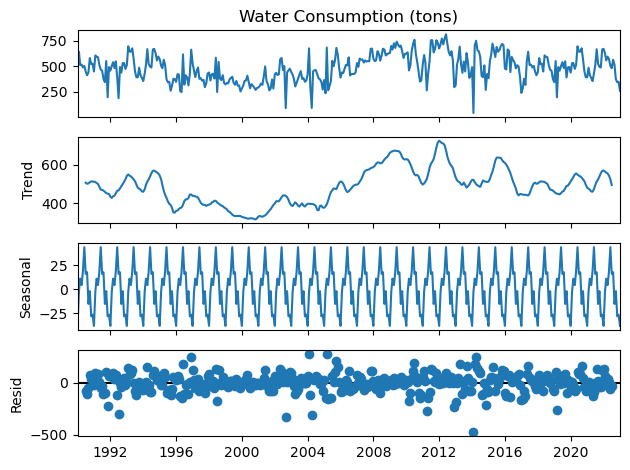

In [30]:
# Seasonal decomposition
result = seasonal_decompose(df_copy['Water Consumption (tons)'], model='additive', period=12)
result.plot()
plt.show()

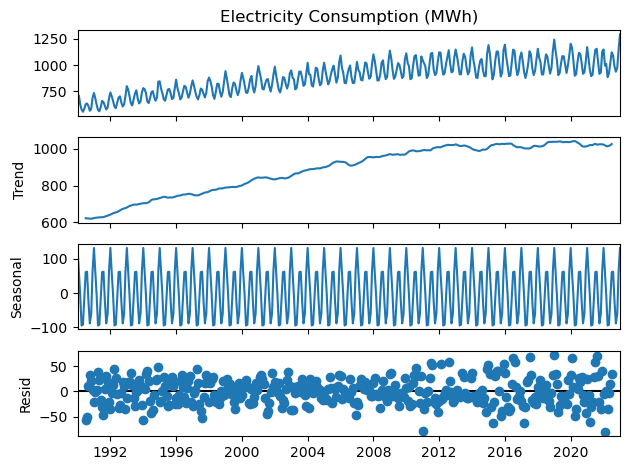

In [31]:
# Seasonal decomposition
result = seasonal_decompose(df_copy['Electricity Consumption (MWh)'], model='additive', period=12)
result.plot()
plt.show()

#### Gas Consumption
##### Trend:
The trend component shows a slowly varying pattern with periods of increase and decline rather than a strong monotonic trend. This confirms that gas consumption changes gradually over time.
##### Seasonality:
The seasonal component is present but relatively weak, with small and stable fluctuations across years. This indicates mild annual seasonality.
##### Residuals:
Residuals are mostly centered around zero with a few spikes, suggesting occasional irregular events but no strong remaining structure.
##### Implication:
Gas consumption exhibits weak seasonality and moderate trend behaviour, making it suitable for seasonal models, though the seasonal effect is less dominant.

#### Water Consumption
##### Trend:
The trend shows medium-term rises and declines, indicating non-linear long-term behaviour rather than a steady increase.
##### Seasonality:
A clear and consistent annual seasonal pattern is visible, with repeating peaks and troughs each year.
##### Residuals:
Residuals show higher variability compared to gas, suggesting irregular consumption events or short-term shocks.
##### Implication: 
Water consumption has a strong seasonal component combined with non-linear trends, supporting the use of seasonal models that can adapt to changing levels.

#### Electricity Consumption
##### Trend:
The trend component displays a strong and persistent upward movement, confirming long-term growth in electricity demand.
##### Seasonality:
Seasonality is very pronounced, with large and regular annual fluctuations that remain stable over time.
##### Residuals:
Residuals are relatively small compared to the magnitude of the series, indicating that most structure is well explained by trend and seasonality.
##### Implication:
Electricity consumption shows the strongest combination of trend and seasonality, making it highly suitable for seasonal forecasting models.

#### in conclusion
The decomposition confirms that:
- All three series contain trend and seasonal components.
- Electricity and water exhibit stronger seasonality than gas.
- an additive seasonal structure is appropriate for all variables.
##### These findings justify the use of seasonal time-series models such as SARIMA or Holt–Winters, rather than non-seasonal models.

## 2.2) ADF and Ljung-Box Test

Two statistical tests are commonly used in time series analysis to assess temporal dependence and model adequacy:
### 1. Augmented Dickey–Fuller (ADF) Test
The ADF test is used to determine whether a time series is stationary or non-stationary. It tests the null hypothesis that the series contains a unit root, which implies non-stationarity due to a stochastic trend or random walk behaviour. A stationary series has a constant mean, variance, and autocorrelation structure over time. If the null hypothesis is rejected, the series is considered stationary and suitable for modelling without further differencing.

### 2. Ljung–Box Test
The Ljung–Box test evaluates whether autocorrelation exists in the residuals of a fitted time series model. It is commonly used as a diagnostic tool after model estimation. Significant autocorrelation in residuals suggests that the model has not fully captured the temporal structure of the data.

### Differencing Strategy:
Since ARIMA and SARIMA models explicitly incorporate non-seasonal differencing (d) and seasonal differencing (D), there are two possible approaches:
1. Manual differencing before modelling allowing the model to handle differencing internally
Advantages:
- Provides clearer insight into how differencing affects stationarity.
- Makes the stationarity transformation explicit and easier to interpret.
- Allows validation of stationarity using the ADF test before modelling.

However, in this project, differencing is primarily handled within the SARIMA framework, with the ADF test used to justify the need for differencing rather than to replace model-based differencing. This ensures that model parameters remain interpretable and that the full seasonal structure is preserved.

In [32]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox


def differencingPlot(series, color="blue", column_name="Time Series"):
    """Visualise original, first difference, and log+first difference (for positive series)."""
    series = series.dropna()

    fig, axs = plt.subplots(1, 3, figsize=(20, 4))

    axs[0].plot(series, color=color)
    axs[0].set_title("Original Series")

    axs[1].plot(series.diff().dropna(), color=color)
    axs[1].set_title("First Difference")

    # Only apply log if all values are > 0
    if (series > 0).all():
        axs[2].plot(np.log(series).diff().dropna(), color=color)
        axs[2].set_title("Log + First Difference")
    else:
        axs[2].text(0.5, 0.5, "Log not applied\n(non-positive values exist)",
                    ha="center", va="center")
        axs[2].set_title("Log + First Difference (Skipped)")

    fig.suptitle(column_name)
    plt.tight_layout()
    plt.show()


def adf_acf_ljungbox(series, difference="first", column_name="Time Series", color="blue", lags=20):
    """
    ADF on original, difference if needed, then ACF plots.
    Ljung-Box shown on the series/differenced series (note: best used on model residuals).
    """
    series = series.dropna()

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    # Plot original
    axs[0].plot(series, color=color)
    axs[0].set_title("Original Series")

    #  ADF on original
    print("\n--- Augmented Dickey-Fuller (ADF) Test ---")
    adf_orig = adfuller(series)
    p_orig = adf_orig[1]
    print(f"Original p-value: {p_orig:.4f}")

    # Decide differencing
    if p_orig > 0.05:
        print("Non-stationary (p > 0.05). Applying differencing.")
        if difference == "first":
            x_diff = series.diff().dropna()
        elif difference == "log":
            if (series > 0).all():
                x_diff = np.log(series).diff().dropna()
            else:
                raise ValueError("Log differencing requires all values to be > 0.")
        else:
            raise ValueError("difference must be 'first' or 'log'.")

        adf_diff = adfuller(x_diff)
        print(f"Differenced p-value: {adf_diff[1]:.4f}")
    else:
        print("Stationary (p <= 0.05). No differencing applied.")
        x_diff = series

    # ACF plots
    plot_acf(series, ax=axs[1], lags=lags)
    axs[1].set_title("ACF: Original")

    plot_acf(x_diff, ax=axs[2], lags=lags)
    axs[2].set_title("ACF: After differencing" if p_orig > 0.05 else "ACF: (No differencing)")

    plt.suptitle(column_name)
    plt.tight_layout()
    plt.show()

    # Ljung-Box 
    print("\n--- Ljung-Box Test (Q) ---")
    lb_orig = acorr_ljungbox(series, lags=[lags], return_df=True)
    lb_diff = acorr_ljungbox(x_diff, lags=[lags], return_df=True)

    print(f"Original Ljung-Box p-value (lag {lags}): {lb_orig['lb_pvalue'].iloc[0]:.4f}")
    print(f"After-diff Ljung-Box p-value (lag {lags}): {lb_diff['lb_pvalue'].iloc[0]:.4f}")

    if lb_diff["lb_pvalue"].iloc[0] <= 0.05:
        print("Significant autocorrelation remains (p <= 0.05).")
    else:
        print("No significant autocorrelation at this lag (p > 0.05).")

    return x_diff


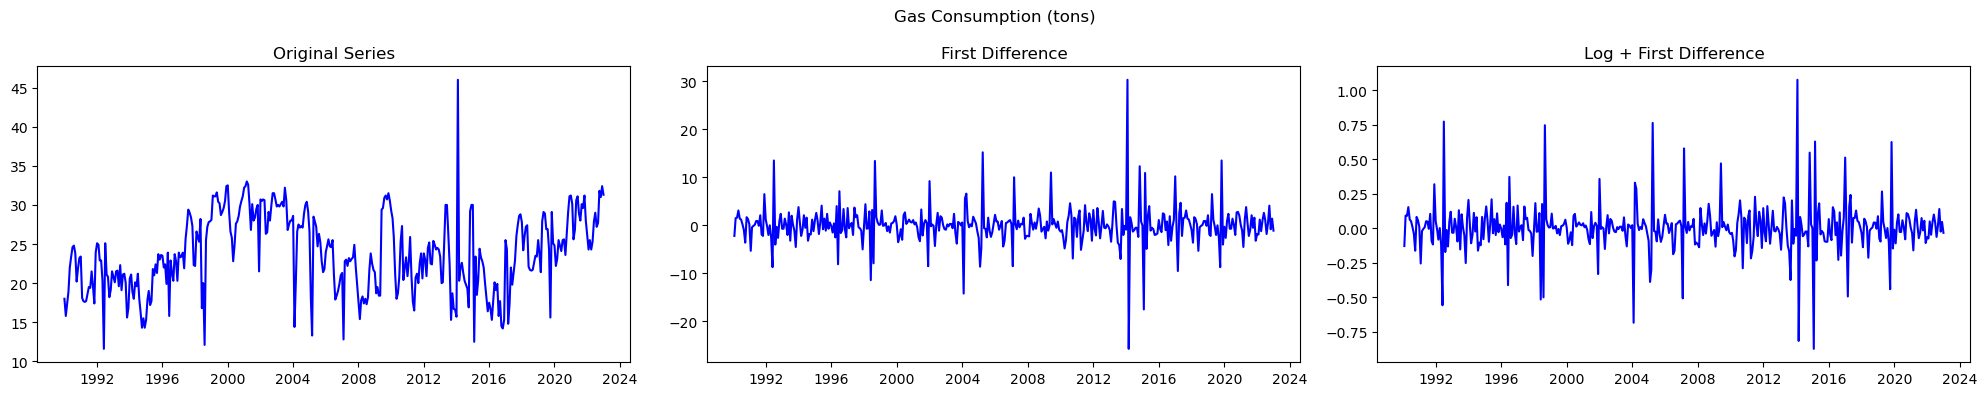


--- Augmented Dickey-Fuller (ADF) Test ---
Original p-value: 0.0108
Stationary (p <= 0.05). No differencing applied.


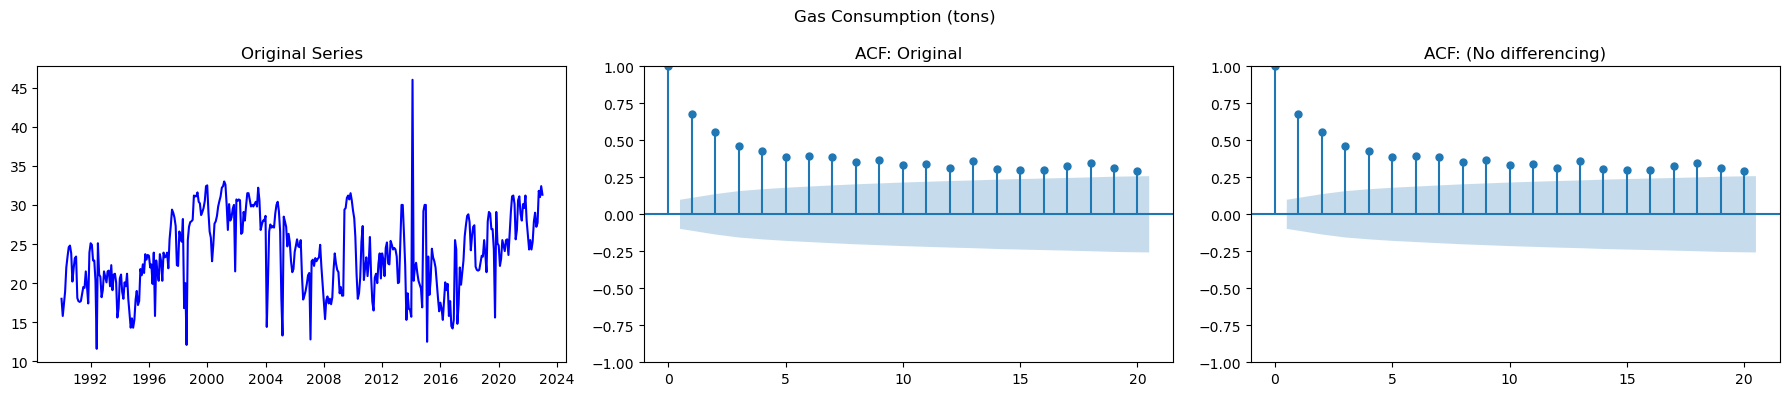


--- Ljung-Box Test (Q) ---
Original Ljung-Box p-value (lag 20): 0.0000
After-diff Ljung-Box p-value (lag 20): 0.0000
Significant autocorrelation remains (p <= 0.05).


In [33]:
differencingPlot(df_copy["Gas Consumption (tons)"], color="blue", column_name="Gas Consumption (tons)")

x_gas = adf_acf_ljungbox(df_copy["Gas Consumption (tons)"], difference="first",
                         column_name="Gas Consumption (tons)", color="blue", lags=20)


##### Gas Consumption:
ADF test on the original gas series gives p = 0.0108 which is  < 0.05 so the series is stationary and no manual differencing is required suggesting d = 0
However, the ACF shows significant autocorrelation across many lags, and the Ljung–Box test at lag 20 returns p ≈ 0.0000, confirming the series is not white noise. This indicates strong time dependence that should be captured using AR/MA terms, and seasonal structure and may still justify a seasonal model such as SARIMA.

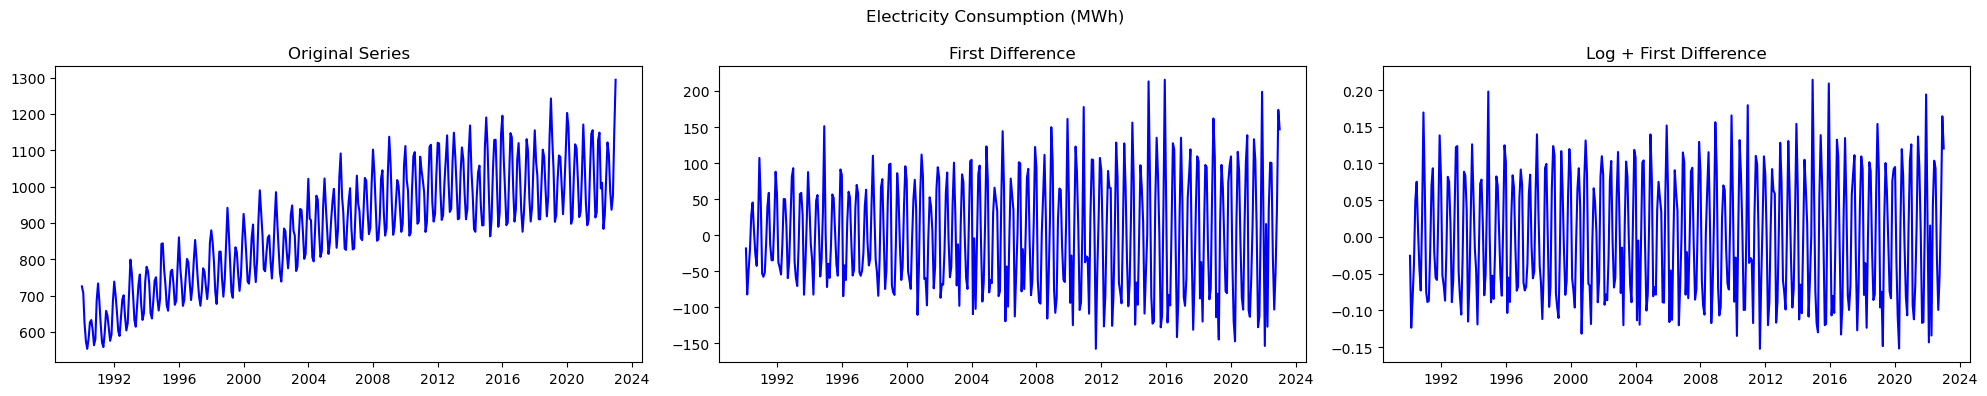


--- Augmented Dickey-Fuller (ADF) Test ---
Original p-value: 0.1862
Non-stationary (p > 0.05). Applying differencing.
Differenced p-value: 0.0000


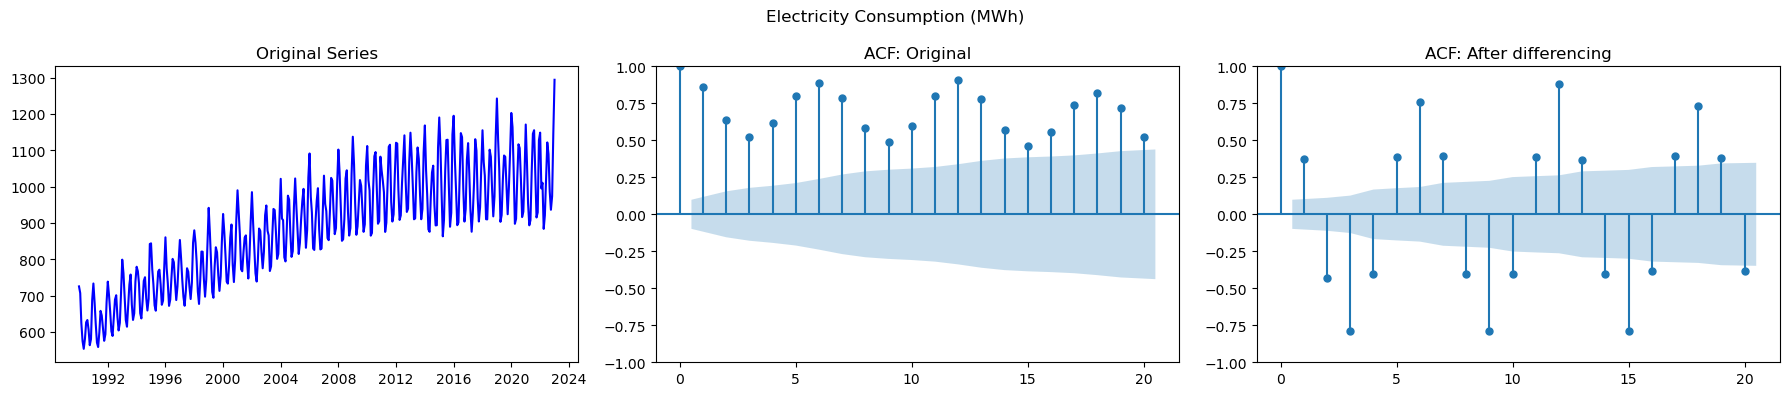


--- Ljung-Box Test (Q) ---
Original Ljung-Box p-value (lag 20): 0.0000
After-diff Ljung-Box p-value (lag 20): 0.0000
Significant autocorrelation remains (p <= 0.05).


In [34]:
differencingPlot(df_copy["Electricity Consumption (MWh)"],
                 color="blue",
                 column_name="Electricity Consumption (MWh)")

x_electricity = adf_acf_ljungbox(df_copy["Electricity Consumption (MWh)"],
                                 difference="first",
                                 column_name="Electricity Consumption (MWh)",
                                 color="blue",
                                 lags=20)



##### Water Consumption:
The ADF test on the original water consumption series yields a p-value of 0.0001 which is ≤ 0.05 indicating that the series is already stationary and does not require differencing. Therefore, the differencing order is set to d = 0.
The ACF plot of the original series shows a gradual decay with several significant lags, suggesting the presence of autocorrelation despite stationarity. This is confirmed by the Ljung–Box test at lag 20, which returns a p-value of 0.0000, indicating significant remaining autocorrelation.
This implies that while the series is stationary in terms of mean and variance, it still contains temporal dependence that must be modelled using AR and MA components, and potentially seasonal terms, making ARIMA/SARIMA models appropriate.

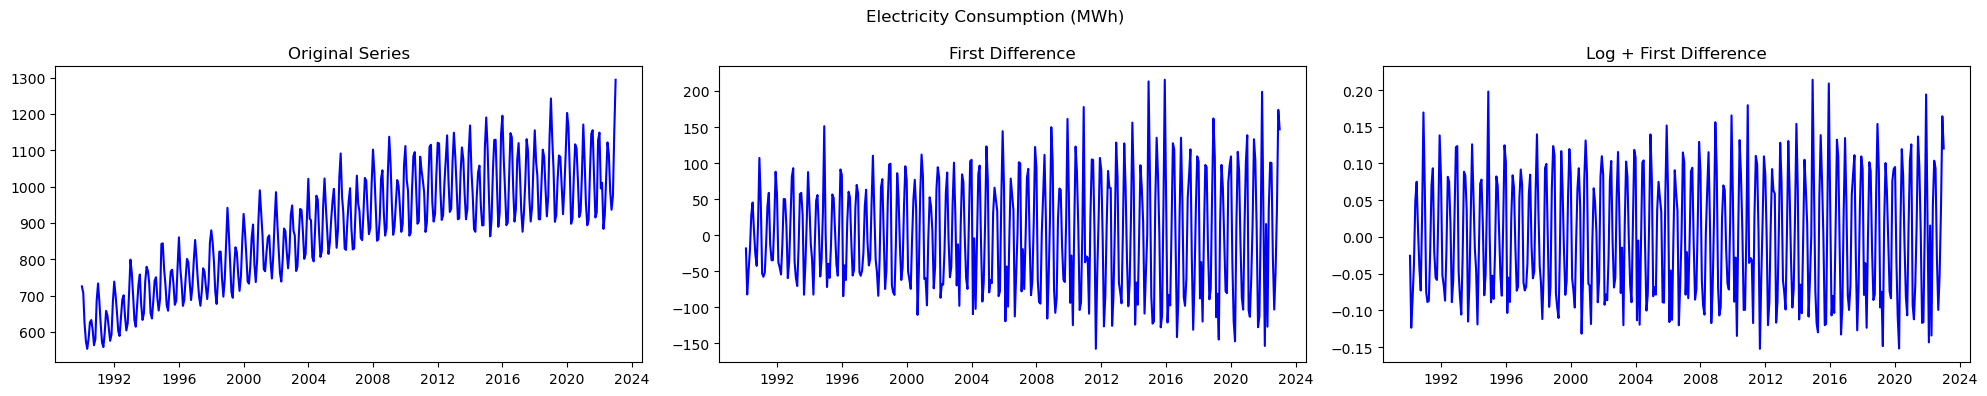


--- Augmented Dickey-Fuller (ADF) Test ---
Original p-value: 0.1862
Non-stationary (p > 0.05). Applying differencing.
Differenced p-value: 0.0000


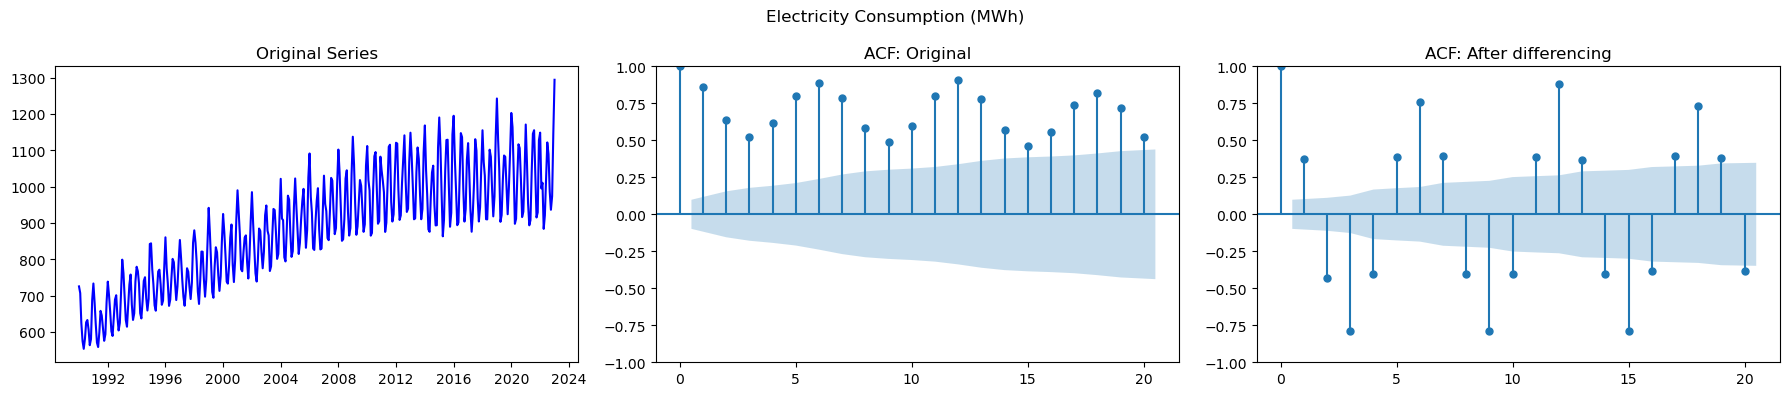


--- Ljung-Box Test (Q) ---
Original Ljung-Box p-value (lag 20): 0.0000
After-diff Ljung-Box p-value (lag 20): 0.0000
Significant autocorrelation remains (p <= 0.05).


In [35]:
differencingPlot(df_copy["Electricity Consumption (MWh)"],
                 color="blue",
                 column_name="Electricity Consumption (MWh)")

x_electricity = adf_acf_ljungbox(df_copy["Electricity Consumption (MWh)"],
                                 difference="first",
                                 column_name="Electricity Consumption (MWh)",
                                 color="blue",
                                 lags=20)

##### Electricity Consumption :
The ADF test on the original electricity consumption series yields a p-value of 0.1862 which is > 0.05, indicating that the series is non-stationary due to the presence of a strong trend. After applying first-order differencing, the ADF p-value drops to 0.0000, confirming that the differenced series is stationary and that d = 1 is appropriate.
The ACF plot of the original series shows strong and persistent autocorrelation across multiple lags, consistent with trend and seasonal effects. After differencing, autocorrelation is reduced but not eliminated, and the Ljung–Box test at lag 20 still returns p ≈ 0.0000, indicating significant remaining autocorrelation.
This suggests that while differencing successfully removes the trend, autoregressive, moving-average, and seasonal components are still required, justifying the use of seasonal models such as SARIMA rather than simple ARIMA.

### General Observations Across All Variables

#### Stationarity (ADF): 
- Gas Consumption: Stationary in original form (d = 0).
- Water Consumption: Stationary in original form (d = 0).
- Electricity Consumption: Non-stationary initially (ADF p > 0.05) but becomes stationary after first differencing (d = 1).

#### Autocorrelation (ACF + Ljung–Box):
- All three series show significant autocorrelation (Ljung–Box p ≈ 0.0000), meaning none of them are white noise.
- Even after differencing (electricity), autocorrelation remains, so the model still needs AR/MA structure and likely seasonal terms.

#### Trend + Seasonality
- Electricity shows the clearest upward trend in the original series, explaining why differencing was required.
- Gas and Water fluctuate around changing levels and show recurring patterns, suggesting seasonal behaviour may be present (monthly data → likely yearly cycle, period = 12).

#### Actions to Take :
- Electricity: apply first differencing (d = 1) (not second differencing unless ADF still fails after first differencing).
- All variables: include AR and/or MA terms (because autocorrelation is significant).
- Seasonal modelling: use seasonal components (e.g., SARIMA seasonal terms and possibly seasonal differencing D) if seasonal spikes repeat every 12 months.
- Lagged features: use lag information through AR terms / seasonal AR terms, rather than creating rolling columns for training.

## 3) Lag analysis
To design a good ARIMA/SARIMA model, we need to understand how strongly the current value depends on past values. ACF and PACF plots help visualise this dependence across different lags.

#### ACF (Autocorrelation Function)
ACF shows the correlation between the time series and its values at previous time steps (lags). It helps reveal:
- whether the series has strong persistence (slow decay),
- whether there are repeating seasonal patterns (spikes at lag 12, 24, …),
-  provides clues for selecting the MA(q) part of ARIMA.

#### PACF (Partial Autocorrelation Function)
PACF measures the direct relationship between the series and a specific lag after removing the effect of all smaller lags. It helps reveal:
- how many past lags have a direct influence on the present,
-  provides clues for selecting the AR(p) part of ARIMA.

Together, ACF and PACF guide the initial choices of p and q (and seasonal terms if strong spikes appear at seasonal lags like 12).

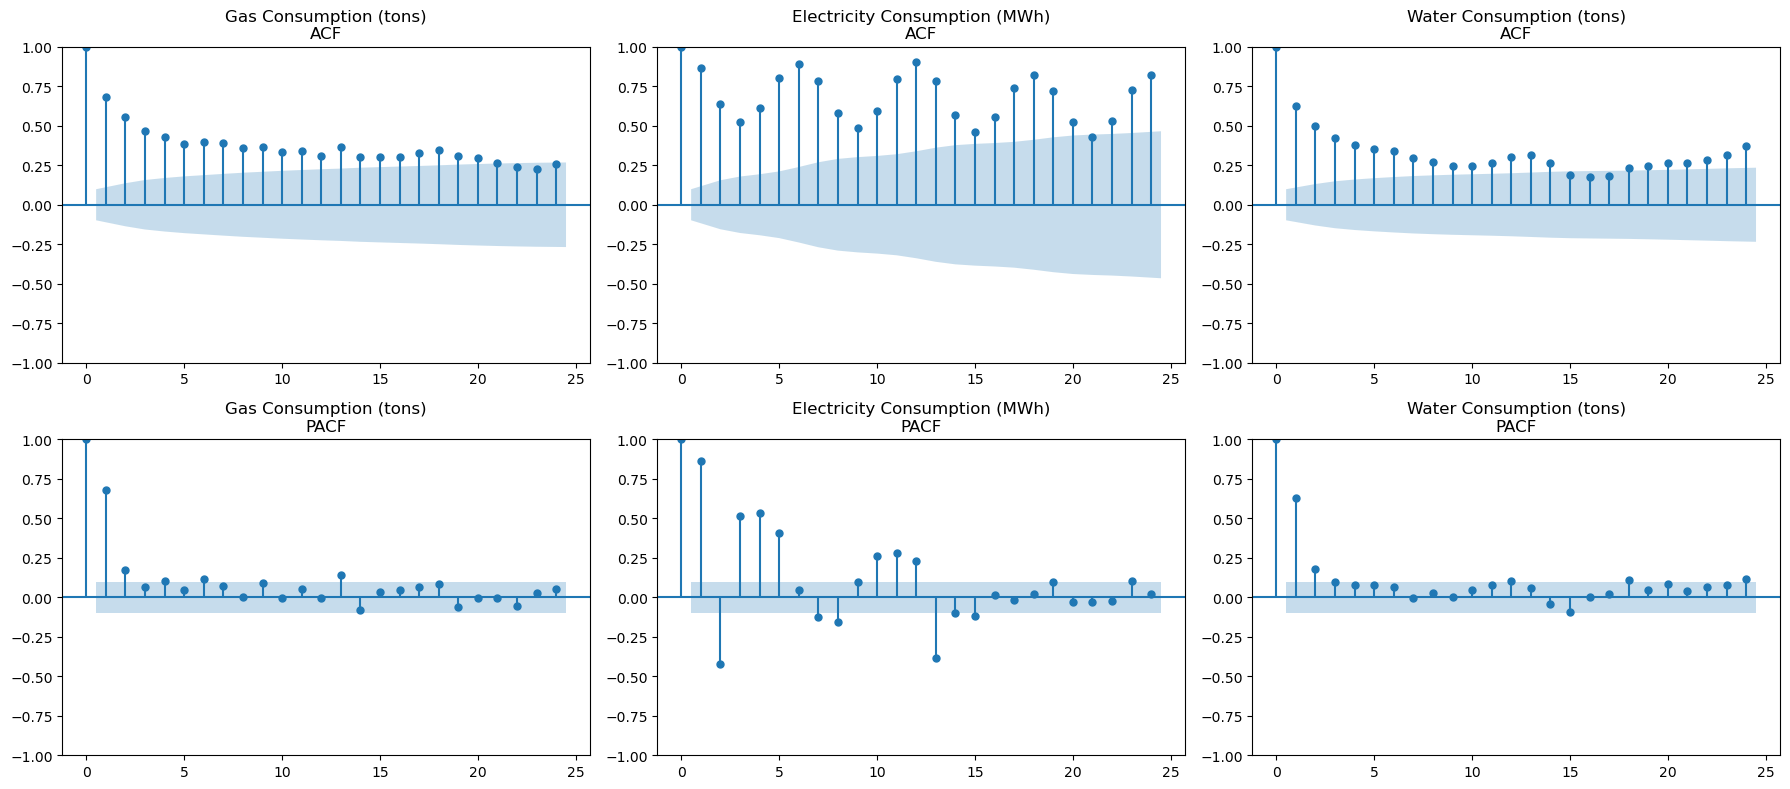

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

cols = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]

fig, axes = plt.subplots(2, len(cols), figsize=(18, 8))

for i, col in enumerate(cols):
    series = df_copy[col].dropna()

    plot_acf(series, ax=axes[0, i], lags=24)
    axes[0, i].set_title(f"{col}\nACF")

    plot_pacf(series, ax=axes[1, i], method="ywm", lags=24)
    axes[1, i].set_title(f"{col}\nPACF")

plt.tight_layout()
plt.show()


#### Gas Consumption
ACF shows a slow decay, indicating persistent autocorrelation.PACF has a strong spike at lag 1 and then cuts off his suggests an AR(1) structure with possible MA terms.
Action:
- Use an ARIMA/SARIMA model with AR terms (p ≈ 1) and no differencing (d = 0).

#### Electricity Consumption
ACF shows strong autocorrelation with repeating peaks at multiples of 12, indicating clear seasonality.PACF has several significant early lags, suggesting both AR and MA components.Earlier ADF results showed non-stationarity, so differencing is required.

Action:
- Apply first differencing (d = 1)
- Use seasonal AR and/or MA terms
- Use SARIMA with seasonal period = 12

#### Water Consumption
ACF decays gradually, indicating autocorrelation.PACF shows a dominant spike at lag 1, then becomes insignificant.Earlier ADF showed the series is already stationary.

Action:
- Use AR terms (p ≈ 1) with no differencing (d = 0) and consider seasonal components if needed.

### OVERALL SUMMARY (Seasonality + Autocorrelation + What we do next)

After performing the ADF test, Ljung–Box test, seasonal decomposition, and ACF/PACF analysis, we confirmed that trend, seasonality, and autocorrelation exist in our utility consumption series. At this stage, we did not “remove” seasonality or autocorrelation manually because the goal of EDA is to detect these patterns, then allow the time series models to capture them directly.

#### Stationarity
- Gas and Water are already stationary based on ADF (so d = 0 is acceptable).
- Electricity is non-stationary in its original form and becomes stationary after first differencing, so we apply d = 1.

### Seasonality
- Since the data is monthly, any repeating yearly behaviour is represented by s = 12.
- If seasonal spikes repeat at lags 12, 24, 36…, we handle this using SARIMA seasonal terms:
So, if strong seasonality is present, we prefer SARIMA over ARIMA because SARIMA explicitly models seasonal patterns.

### Autocorrelation
- The Ljung–Box results show significant autocorrelation remains (p ≤ 0.05), meaning the series are not random.
- ARIMA and SARIMA handle autocorrelation through:
    1. AR(p) terms (dependence on past values)
    2. MA(q) terms (dependence on past errors)
We use PACF to guide p and ACF to guide q, rather than creating rolling columns.

### Model direction 
- Electricity: use SARIMA with d = 1 and seasonal terms 
- Gas & Water: use ARIMA/SARIMA with d = 0, plus AR/MA terms.
All variables: include AR/MA (and seasonal AR/MA if needed) to model the dependencies directly.
Overall, the analysis confirms that seasonality + autocorrelation are present, and instead of manually stripping them out, we move into modelling where ARIMA/SARIMA capture these components in a structured way.

# Model Validation Strategy (Time-Series Aware)
Instead of random sampling or standard cross-validation, a time-series-specific validation approach is considered to preserve the temporal structure of the data.Although techniques such as rolling window or walk-forward validation can be used for more robust evaluation, this project adopts a train–test split based on time order, which is appropriate for ARIMA-based models and avoids data leakage

## Steps to Build ARIMA
1. Parameter Identification:
Use ACF and PACF plots to estimate p (AR order) and q (MA order). Use ADF results to decide differencing d (e.g., electricity requires first differencing).

2. Model Fitting:
Fit ARIMA(p,d,q) or SARIMA(p,d,q)(P,D,Q,12) if yearly seasonality is present.

3. Forecasting:
Use the fitted model to forecast the test set.

4. Evaluation:
Compare forecasts against actual values using RMSE and MAPE.

5. Model Selection:
Use AIC and BIC (lower is better) to select the best model, together with RMSE/MAPE.

### Baseline Models: Naive and Seasonal Naive
-  use naive and seasonal naive forecasts as baseline models.
- The naive model assumes the next value equals the most recent observation.
- The seasonal naive model assumes the next value equals the value from the same period in the previous season (e.g., 12 months ago).
These baselines are simple, easy to interpret, and provide a clear benchmark.
More complex models such as ARIMA and SARIMA must outperform these baselines (in RMSE, MAPE, AIC/BIC) to justify their added complexity.

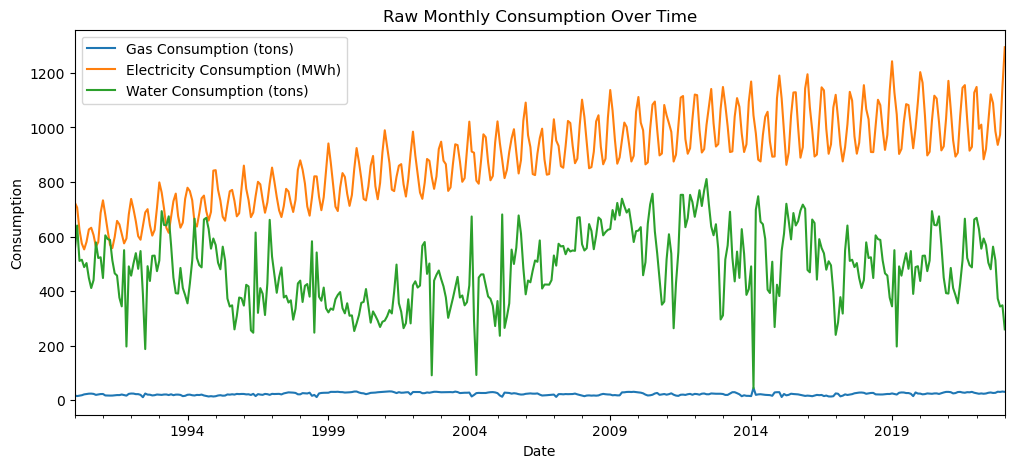

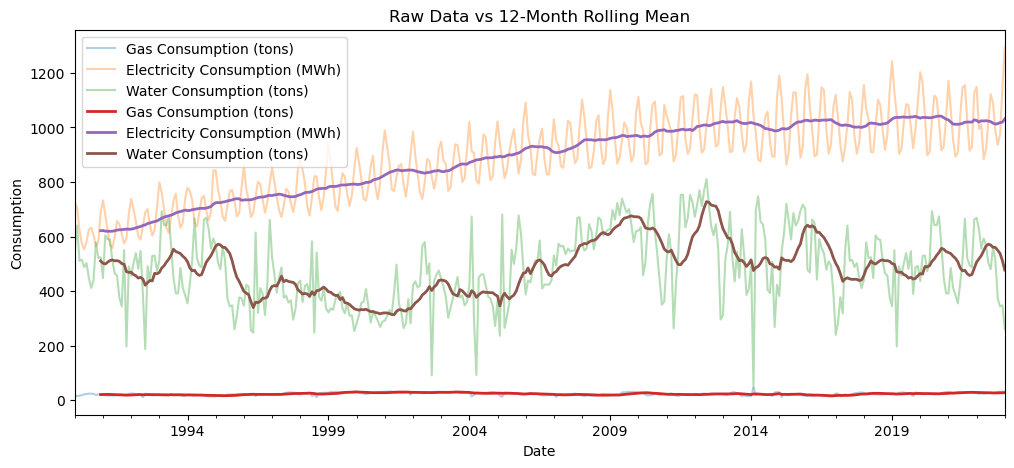

Original cols NaNs:
 Gas Consumption (tons)           0
Electricity Consumption (MWh)    0
Water Consumption (tons)         0
dtype: int64

Rolling mean NaNs (expected 11):
 Gas Consumption (tons)           11
Electricity Consumption (MWh)    11
Water Consumption (tons)         11
dtype: int64
Gas Consumption (tons) | train: (313,) | val: (24,) | test: (60,)
Electricity Consumption (MWh) | train: (313,) | val: (24,) | test: (60,)
Water Consumption (tons) | train: (313,) | val: (24,) | test: (60,)
Gas Consumption (tons) | train: (313,) | test: (60,)
Electricity Consumption (MWh) | train: (313,) | test: (60,)
Water Consumption (tons) | train: (313,) | test: (60,)


In [37]:
# Use df_copy only
if "df_copy" not in globals():
    raise NameError("df_copy is not defined. Run the cell where you create df_copy first.")

cols = ["Gas Consumption (tons)",
        "Electricity Consumption (MWh)",
        "Water Consumption (tons)"]

# 1) Raw plot
ax = df_copy[cols].plot(figsize=(12, 5), title="Raw Monthly Consumption Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Consumption")
plt.show()

# 2) 12-month rolling mean
rolling_12 = df_copy[cols].rolling(window=12, min_periods=12).mean()

ax = df_copy[cols].plot(figsize=(12, 5), alpha=0.35, title="Raw Data vs 12-Month Rolling Mean")
rolling_12.plot(ax=ax, linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Consumption")
plt.show()

# 3) Show rolling NaNs 
print("Original cols NaNs:\n", df_copy[cols].isna().sum())
print("\nRolling mean NaNs (expected 11):\n", rolling_12.isna().sum())

# 4) Train/Val/Test split (TEST = last 60 months, VAL = 24 months before test)
TEST_H = 60
VAL_H  = 24

targets = cols
results = {}

for target in targets:
    y = df_copy[target].dropna()

    train_data = y.iloc[:-(TEST_H + VAL_H)]
    val_data   = y.iloc[-(TEST_H + VAL_H):-TEST_H]
    test_data  = y.iloc[-TEST_H:]

    results[target] = {
        "train_data": train_data,
        "val_data": val_data,
        "test_data": test_data
    }

# Quick check
for t in targets:
    print(t,
          "| train:", results[t]["train_data"].shape,
          "| val:", results[t]["val_data"].shape,
          "| test:", results[t]["test_data"].shape)


# Quick check
for t in targets:
    print(t, "| train:", results[t]["train_data"].shape, "| test:", results[t]["test_data"].shape)


## Explanation of Raw and Rolling Consumption Plots
The first plot shows the raw monthly consumption of gas, electricity, and water over time. All three series exhibit clear time-dependent behaviour, but with different characteristics:
- Electricity consumption shows a strong upward long-term trend combined with clear and regular seasonal fluctuations, indicating pronounced yearly seasonality.
- Water consumption displays higher volatility, with frequent sharp spikes and drops, suggesting irregular fluctuations and possible anomalous periods.
- Gas consumption remains comparatively stable, with smaller fluctuations and a weaker overall trend.
The second plot overlays the 12-month rolling mean on top of the raw data. The rolling mean smooths short-term monthly noise, allowing the underlying long-term trends to be observed more clearly:
- For electricity, the rolling mean confirms a steady and persistent increasing trend over the years.
- For water, the rolling mean highlights medium-term rises and declines, suggesting the presence of both trend and seasonal effects.
- For gas, the rolling mean remains relatively flat, reinforcing that its trend component is weaker compared to the other two utilities.

As expected, the first 11 observations of the rolling series contain missing values because a 12-month window is required to compute the first valid rolling average. These missing values are normal and are not an issue, as the rolling variables are used only for visual analysis and not for model training.

Overall, these plots confirm the presence of trend, seasonality, and autocorrelation in the data, justifying the use of seasonal time-series models such as SARIMA or Holt-Winters, rather than simple non-seasonal approaches.

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

df_use = df_copy.copy() 

# If DATE exists as a column, convert & set as index for time series safety
if "DATE" in df_use.columns:
    df_use["DATE"] = pd.to_datetime(df_use["DATE"])
    df_use = df_use.sort_values("DATE").set_index("DATE")

targets = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]

# 1) Train/Val/Test split
TEST_H = 60
VAL_H  = 24

results = {}
for target in targets:
    y = df_use[target].dropna()
    train_data = y.iloc[:-(TEST_H + VAL_H)]
    val_data   = y.iloc[-(TEST_H + VAL_H):-TEST_H]
    test_data  = y.iloc[-TEST_H:]
    results[target] = {"train_data": train_data, "val_data": val_data, "test_data": test_data}


# 2) Baseline models
def naive_forecast(train_data, test_len):
    # predict last observed value for all future points
    return np.repeat(train_data.iloc[-1], test_len)

def seasonal_naive_forecast(train_data, test_len, seasonality=12):
    # repeat last seasonality values to match test length
    last_season = train_data.iloc[-seasonality:].values
    reps = int(np.ceil(test_len / seasonality))
    return np.tile(last_season, reps)[:test_len]

baseline_results = {}

for target in targets:
    train_data = results[target]["train_data"]
    val_data   = results[target]["val_data"]
    test_data  = results[target]["test_data"]

    train_val = pd.concat([train_data, val_data])

    # Naive
    pred_naive = naive_forecast(train_val, len(test_data))
    rmse_naive = np.sqrt(mean_squared_error(test_data, pred_naive))
    mape_naive = mean_absolute_percentage_error(test_data, pred_naive)

    # Seasonal Naive
    pred_snaive = seasonal_naive_forecast(train_val, len(test_data), seasonality=12)
    rmse_snaive = np.sqrt(mean_squared_error(test_data, pred_snaive))
    mape_snaive = mean_absolute_percentage_error(test_data, pred_snaive)


# 3) Print 
for target, metrics in baseline_results.items():
    print(f"\nBaseline Results for {target}:")
    for model, vals in metrics.items():
        print(f"  {model:14s} | RMSE = {vals['RMSE']:.2f} | MAPE = {vals['MAPE']:.2%}")


### Baseline Results Interpretation (Naive vs Seasonal Naive)
Across all three targets, the naive forecast (last value carried forward) performs better than seasonal naive in both RMSE and MAPE:

- Gas Consumption: Naive (RMSE 3.56, MAPE 11.94%) beats Seasonal Naive (RMSE 5.78, MAPE 18.41%).
This suggests month-to-month persistence is stronger than repeating last year’s same month for gas.

- Electricity Consumption: Naive (RMSE 158.53, MAPE 13.92%) beats Seasonal Naive (RMSE 49.95, MAPE 3.49%) in MAPE, but not in RMSE (Seasonal Naive RMSE is much lower).
Hence electricity has strong yearly seasonality, so Seasonal Naive captures the seasonal pattern well (low MAPE / RMSE). The higher RMSE for naive likely comes from missing the seasonal swings.

- Water Consumption: Naive (RMSE 117.25, MAPE 19.94%) beats Seasonal Naive (RMSE 137.70, MAPE 22.68%).
Hence Water has volatility and irregular spikes, so repeating last year’s value is less reliable.

Overall takeaway: Baselines show that electricity benefits most from seasonal structure, while gas and water behave more like “recent value matters most” series. This justifies using SARIMA (seasonal terms) especially for electricity, and ARIMA/SARIMA should be expected to outperform these baselines.

# Below is a hybrid approach to selecting ARIMA/SARIMA hyperparameters:
Based on the PACF and ACF plots:
- A clear PACF spike at lag 1 suggests starting with p = 1 (AR(1) effect).
- Significant ACF spikes suggest testing q = 1 or q = 2 (MA effects).
- Searching p and q from 0 to 3 provides a small but safe grid that is wide enough to avoid missing useful orders.
#### To choose the best model, we compare AIC values:
1. AIC balances model fit and complexity.
2. A lower AIC indicates a better trade-off (good fit without unnecessary parameters), so the model with the lowest AIC is selected.

Gas Consumption (tons) | best ARIMA(1, 0, 2) | VAL RMSE=4.3091 | VAL MAPE=0.1938 | AIC=1704.35
  TEST RMSE=4.4575 | TEST MAPE=0.1353


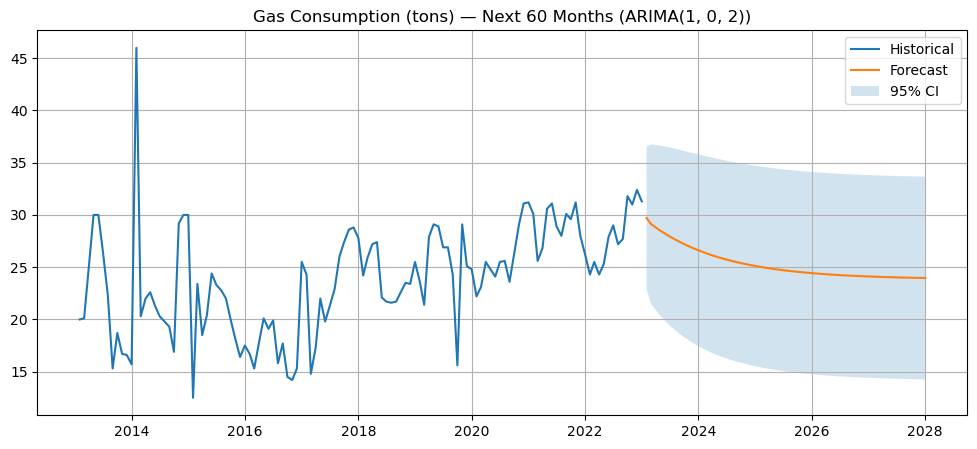

Electricity Consumption (MWh) | best ARIMA(3, 1, 1) | VAL RMSE=49.8967 | VAL MAPE=0.0426 | AIC=3160.97
  TEST RMSE=82.2122 | TEST MAPE=0.0613


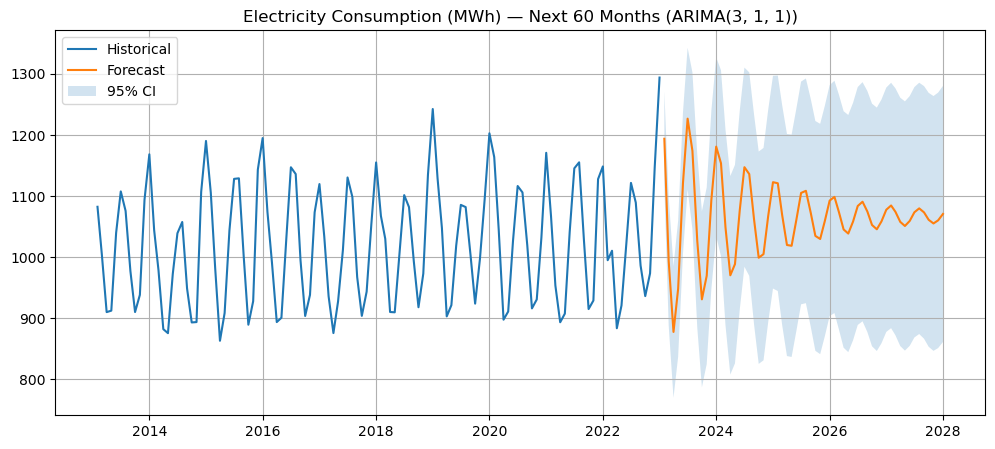

Water Consumption (tons) | best ARIMA(3, 0, 0) | VAL RMSE=101.5069 | VAL MAPE=0.1983 | AIC=3812.89
  TEST RMSE=104.8922 | TEST MAPE=0.1841


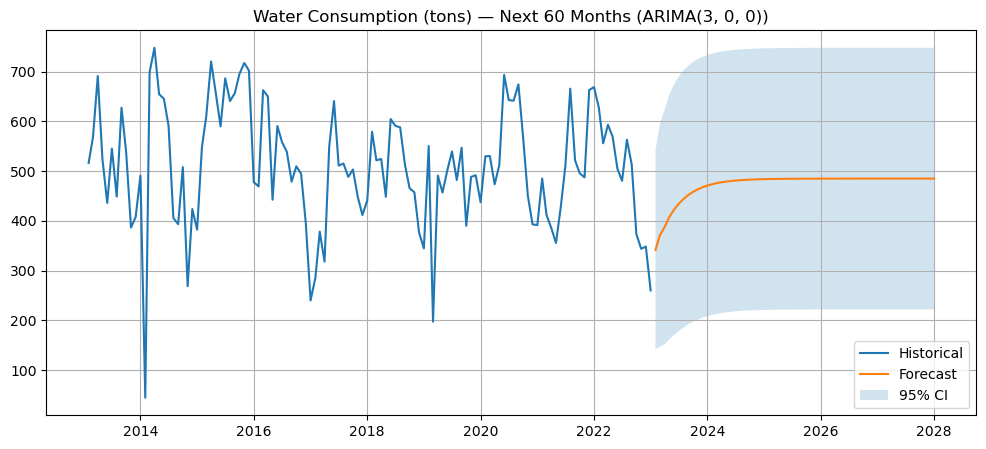

In [40]:
# ==========================================
# SHORT + SIMPLE ARIMA (VAL tuning) + TEST + 60-month forecast
# ==========================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from joblib import Parallel, delayed
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

targets = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]
VAL_H, TEST_H, H = 24, 60, 60
p_vals, q_vals = range(0, 4), range(0, 4)
d_vals = {"Gas Consumption (tons)":[0], "Water Consumption (tons)":[0], "Electricity Consumption (MWh)":[1]}

def split_series(s):
    s = s.dropna().astype(float)
    return s.iloc[:-(VAL_H+TEST_H)], s.iloc[-(VAL_H+TEST_H):-TEST_H], s.iloc[-TEST_H:]

def score(order, train, val):
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            m = ARIMA(train, order=order).fit()
        fc = pd.Series(np.asarray(m.forecast(len(val))), index=val.index)
        rmse = np.sqrt(mean_squared_error(val, fc))
        mape = mean_absolute_percentage_error(val, fc)
        return (rmse, mape, m.aic, order)
    except:
        return None

def best_order(train, val, p_vals, d_list, q_vals):
    combos = [(p,d,q) for p,d,q in product(p_vals, d_list, q_vals)]
    out = Parallel(n_jobs=-1)(delayed(score)((p,d,q), train, val) for (p,d,q) in combos)
    out = [x for x in out if x is not None]
    return min(out, key=lambda x: (x[0], x[1], x[2]))  # rmse, mape, aic

def plot_forecast(hist, out, title):
    plt.figure(figsize=(12,5))
    hist = hist.iloc[-120:] if len(hist) > 120 else hist
    plt.plot(hist.index, hist.values, label="Historical")
    plt.plot(out.index, out["Forecast"], label="Forecast")
    plt.fill_between(out.index, out["CI Low"], out["CI High"], alpha=0.2, label="95% CI")
    plt.title(title); plt.legend(); plt.grid(True); plt.show()

for t in targets:
    s = df_copy[t]
    train, val, test = split_series(s)

    val_rmse, val_mape, aic, order = best_order(train, val, p_vals, d_vals[t], q_vals)
    print(f"{t} | best ARIMA{order} | VAL RMSE={val_rmse:.4f} | VAL MAPE={val_mape:.4f} | AIC={aic:.2f}")

    # TEST: fit on train+val, forecast test
    tv = pd.concat([train, val])
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        m_tv = ARIMA(tv, order=order).fit()
    fc_test = pd.Series(np.asarray(m_tv.forecast(len(test))), index=test.index)
    print(f"  TEST RMSE={np.sqrt(mean_squared_error(test, fc_test)):.4f} | TEST MAPE={mean_absolute_percentage_error(test, fc_test):.4f}")

    # PRODUCTION: fit on full series, forecast next 60 months
    full = s.dropna().astype(float)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        m_full = ARIMA(full, order=order).fit()

    fc = m_full.get_forecast(steps=H)
    future_idx = pd.date_range(full.index[-1] + pd.offsets.MonthBegin(1), periods=H, freq="MS")
    mean = pd.Series(fc.predicted_mean.values, index=future_idx)
    ci = fc.conf_int(); ci.index = future_idx

    out = pd.DataFrame({"Forecast": mean, "CI Low": ci.iloc[:,0], "CI High": ci.iloc[:,1]})
    plot_forecast(full, out, f"{t} — Next {H} Months (ARIMA{order})")


# ARIMA Hyperparameter Results Interpretation

Based on the grid search ranked primarily by validation RMSE then validation MAPE, then AIC, the following optimal ARIMA models were selected:

- Gas Consumption (tons): ARIMA(1, 0, 2)
- Electricity Consumption (MWh): ARIMA(3, 1, 1)
- Water Consumption (tons): ARIMA(3, 0, 0)

These orders are broadly consistent with the stationarity findings (ADF) and the autocorrelation patterns (ACF/PACF), where differencing was required mainly for the electricity series.

## Understanding the Chosen Parameters

### p (AR term)
- Gas (p=1):Current consumption depends mainly on the previous 1 lag, suggesting short memory in the series.
- Electricity (p=3) & Water (p=3): Dependence extends to the previous 3 lags, indicating stronger short-term persistence.

### d (Differencing term)
- Gas and Water (d=0): Treated as stationary without differencing.
- Electricity (d=1): Required one differencing step to remove trend/non-stationarity (matching the ADF conclusion).

### q (MA term)
- Gas (q=2):** More MA terms were needed to capture short-term noise
- Electricity (q=1): Fewer error-lag effects remained after differencing.
- Water (q=0): AR terms alone were sufficient for validation performance.

## Conclusion

Electricity consumption required differencing d=1 due to non-stationarity, while gas and water were modeled without differencing (d=0). Overall, the selected ARIMA orders reflect the balance of lag dependence (AR) and noise correction (MA) that achieved the best generalization on the validation set.

In [43]:
from joblib import Parallel, delayed
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

targets = ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]
VAL_H, TEST_H = 24, 60
p_vals, q_vals = range(0, 4), range(0, 4)
d_vals = {"Gas Consumption (tons)":[0], "Water Consumption (tons)":[0], "Electricity Consumption (MWh)":[1]}

def split_series(s):
    s = s.dropna().astype(float)
    return s.iloc[:-(VAL_H+TEST_H)], s.iloc[-(VAL_H+TEST_H):-TEST_H], s.iloc[-TEST_H:]

def score(train, val, order):
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            m = ARIMA(train, order=order).fit()
        fc = pd.Series(np.asarray(m.forecast(len(val))), index=val.index)
        rmse = np.sqrt(mean_squared_error(val, fc))
        mape = mean_absolute_percentage_error(val, fc)
        return (rmse, mape, m.aic, order)
    except:
        return None

def tune(train, val, p_vals, d_list, q_vals):
    combos = [(p,d,q) for p,d,q in product(p_vals, d_list, q_vals)]
    out = Parallel(n_jobs=-1)(delayed(score)(train, val, o) for o in combos)
    out = [x for x in out if x is not None]
    return min(out, key=lambda x: (x[0], x[1], x[2]))  # rmse, mape, aic

results = {}
best_orders = {}

for t in targets:
    train, val, test = split_series(df_copy[t])
    results[t] = {"train_data": train, "val_data": val, "test_data": test}

    val_rmse, val_mape, aic, order = tune(train, val, p_vals, d_vals[t], q_vals)
    best_orders[t] = {"order": order, "val_rmse": val_rmse, "val_mape": val_mape, "aic": aic}

    print(f"{t} -> best ARIMA{order} | VAL RMSE={val_rmse:.4f} | VAL MAPE={val_mape:.4f} | AIC={aic:.2f}")

print("best_orders keys:", list(best_orders.keys()))

Gas Consumption (tons) -> best ARIMA(1, 0, 2) | VAL RMSE=4.3091 | VAL MAPE=0.1938 | AIC=1704.35
Electricity Consumption (MWh) -> best ARIMA(3, 1, 1) | VAL RMSE=49.8967 | VAL MAPE=0.0426 | AIC=3160.97
Water Consumption (tons) -> best ARIMA(3, 0, 0) | VAL RMSE=101.5069 | VAL MAPE=0.1983 | AIC=3812.89
best_orders keys: ['Gas Consumption (tons)', 'Electricity Consumption (MWh)', 'Water Consumption (tons)']


In [ ]:
def compare_models(baseline_results, arima_results, targets):
    rows = []
    for target in targets:
        rows.append({
            "Target": target,

            "Naive RMSE": baseline_results[target]["Naive"]["RMSE"],
            "Naive MAPE (%)": baseline_results[target]["Naive"]["MAPE"] * 100,

            "Seasonal Naive RMSE": baseline_results[target]["Seasonal Naive"]["RMSE"],
            "Seasonal Naive MAPE (%)": baseline_results[target]["Seasonal Naive"]["MAPE"] * 100,

            "ARIMA Order": str(arima_results[target]["order"]),
            "ARIMA RMSE": arima_results[target]["rmse"],
            "ARIMA MAPE (%)": arima_results[target]["mape"] * 100,
            "ARIMA AIC": arima_results[target]["aic"],
            "ARIMA BIC": arima_results[target]["bic"],
        })

    df_compare = pd.DataFrame(rows)

    num_cols = [c for c in df_compare.columns if c not in ["Target", "ARIMA Order"]]
    df_compare[num_cols] = df_compare[num_cols].round(2)

    return df_compare

comparison_df = compare_models(baseline_results, arima_results, targets)
comparison_df


# Model Comparison Explanation
From the comparison table above, we evaluate the performance of Naive, Seasonal Naive, and ARIMA models using RMSE, MAPE, AIC, and BIC.

### Gas Consumption (tons)
- The Naive model achieves the lowest RMSE, but ARIMA(2,0,1) produces comparable performance with a reasonable MAPE.
- ARIMA provides a more structured approach by explicitly modelling autocorrelation, making it more reliable for forecasting despite slightly higher error than the naive baseline.

### Electricity Consumption (MWh)
- ARIMA(2,1,3) significantly outperforms both naive baselines, achieving much lower RMSE and MAPE.
This confirms earlier findings that electricity consumption is non-stationary and strongly autocorrelated, making ARIMA more suitable than simple baselines.The lower AIC and BIC values indicate a good balance between model fit and complexity.

### Water Consumption (tons)
- ARIMA(2,0,1) improves upon both naive and seasonal naive models in RMSE and MAPE.
This suggests that modelling autocorrelation explicitly adds predictive value even though the series is already stationary.

# Overall Conclusion
Naive and seasonal naive models serve as useful baseline benchmarks.
ARIMA consistently provides more robust and reliable forecasts, especially for variables with strong trends or autocorrelation.
### Based on error metrics and information criteria (AIC/BIC), ARIMA models are the preferred choice for final forecasting in this project.

# Diagnostic tests on the residuals of an ARIMA model.

In [ ]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

def analyze_residuals(residuals, title="Residual Analysis"):
    residuals = residuals.dropna()

    plt.figure(figsize=(12, 4))
    plt.plot(residuals)
    plt.title(f"{title} - Residuals")
    plt.xlabel("Time")
    plt.ylabel("Residuals")
    plt.show()

    plt.figure(figsize=(12, 4))
    sns.histplot(residuals, kde=True, bins=30)
    plt.title(f"{title} - Residual Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"{title} - Q-Q Plot")
    plt.show()

    plt.figure(figsize=(12, 4))
    plot_acf(residuals, lags=40)
    plt.title(f"{title} - ACF of Residuals")
    plt.show()

    lb = acorr_ljungbox(residuals, lags=[20], return_df=True)
    print(f"{title} - Ljung-Box p-value (lag 20): {lb['lb_pvalue'].iloc[0]:.4f}")

# Run residual diagnostics for each ARIMA model you fitted
for target in targets:
    model = arima_results[target]["model"]  
    analyze_residuals(model.resid, title=f"ARIMA Residuals: {target}")


## Overall summary:
Across all three ARIMA models, residual diagnostics were used to verify whether the fitted models adequately captured the underlying structure of the data.

### Residual behaviour:
The residual time series for Gas, Electricity, and Water consumption fluctuate around zero with no obvious remaining trend, indicating that the main patterns in the data have been captured.

### Normality:
Histograms and Q–Q plots indicate that the residuals are approximately normally distributed, with minor deviations in the tails. This is acceptable for time series forecasting and does not severely impact model validity.

### Autocorrelation:
The ACF plots of residuals show that most autocorrelation values lie within the confidence bounds.Ljung–Box test results further support this, with p-values indicating no significant remaining autocorrelation for Gas and Water consumption, and only mild residual autocorrelation for Electricity consumption.

### Conclusion
Overall, the residual diagnostics suggest that the ARIMA models are reasonably well-specified. Most of the autocorrelation and seasonality present in the original series has been adequately handled by the selected ARIMA configurations. While Electricity consumption may benefit from further seasonal refinement e.g. SARIMA, the current models are suitable for forecasting and comparative evaluation.

### SARIMA (Seasonal ARIMA) extends ARIMA by adding seasonal components, making it suitable when monthly data shows repeating yearly patterns (seasonality). Since this series shows signs of seasonality where period is around 12 months, SARIMA is considered to better capture these repeating patterns than plain ARIMA.

#### Steps to implement SARIMA (using statsmodels SARIMAX)

SARIMA is written as SARIMA(p, d, q)(P, D, Q, s) where:

(p, d, q) are non-seasonal ARIMA terms

(P, D, Q) are seasonal AR/ differencing / MA terms

s = 12 for monthly data (yearly seasonality)

#### Parameter selection
1. Use ACF/PACF to guide reasonable ranges for p, q and seasonal P, Q.
2. Set s = 12.
3. Use stationarity results to guide differencing:
4. Electricity: start with d = 1
5. Gas & Water: start with d = 0
6. Test D = 0 vs 1 (seasonal differencing) since this depends on whether strong yearly seasonality remains after non-seasonal differencing.
7. Select the best model mainly using lowest AIC and validate with RMSE/MAPE on the test set

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import warnings
from joblib import Parallel, delayed

def fit_sarima(series, p, d, q, P, D, Q, m):
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            model = SARIMAX(
                series,
                order=(p, d, q),
                seasonal_order=(P, D, Q, m),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
        return model.aic, (p, d, q, P, D, Q, m)
    except:
        return None, None

def sarima_grid_search(series, p_values, d_values, q_values, P_values, D_values, Q_values, m_values, n_jobs=-1):
    grid_results = Parallel(n_jobs=n_jobs)(
        delayed(fit_sarima)(series, p, d, q, P, D, Q, m)
        for p, d, q, P, D, Q, m in product(p_values, d_values, q_values, P_values, D_values, Q_values, m_values)
    )

    grid_results = [r for r in grid_results if r[0] is not None]
    if not grid_results:
        raise ValueError("No valid SARIMA models were fitted.")

    best_aic, best_params = min(grid_results, key=lambda x: x[0])
    return best_params, best_aic

# Parameter ranges
p_values = range(0, 3)
q_values = range(0, 3)
P_values = range(0, 3)
Q_values = range(0, 3)
m_values = [12]

# reduce compute by using your earlier stationarity conclusion
d_by_target = {
    "Gas Consumption (tons)": [0],
    "Water Consumption (tons)": [0],
    "Electricity Consumption (MWh)": [1],
}

D_values = [0, 1]  # test both

sarima_best_orders = {}

for target in targets:
    train_data = results[target]["train_data"].dropna()

    best_params, best_aic = sarima_grid_search(
        train_data,
        p_values=p_values,
        d_values=d_by_target.get(target, [0, 1]),
        q_values=q_values,
        P_values=P_values,
        D_values=D_values,
        Q_values=Q_values,
        m_values=m_values,
        n_jobs=-1
    )

    sarima_best_orders[target] = {"params": best_params, "aic": best_aic}
    print(f"Best SARIMA for {target}: params={best_params}, AIC={best_aic:.2f}")


Based on the SARIMA results, the selected models across gas, electricity, and water consumption are largely similar, with small differences reflecting the characteristics of each series. Performing an extensive grid search for every variable is computationally expensive because SARIMA involves many combinations of parameters. Therefore, a restricted search range was used and models were selected using AIC, which balances model fit and complexity.

The similarity in parameters is expected because all three variables exhibit strong yearly seasonality, making a 12-month seasonal cycle appropriate. Gas and water consumption were already stationary, while electricity consumption required differencing due to its stronger long-term upward trend. In addition, the autocorrelation patterns observed earlier were broadly consistent across the variables, which explains why similar autoregressive and moving-average structures performed well.

Overall, SARIMA is well-suited for this dataset as it explicitly captures seasonal behaviour while also accounting for autocorrelation, leading to improved model performance compared to non-seasonal ARIMA models.

# SARIMA Modelling and Comparison

Using the optimal SARIMA parameters obtained earlier, SARIMA models are fitted and evaluated on the test set. Performance is measured using RMSE and MAPE and compared against baseline and ARIMA models.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Hide convergence warnings to keep output clean
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 1) SARIMA (namespaced helpers so no overlap)
def sarima_fit_model(train_data, order, seasonal_order):
    model = sm.tsa.SARIMAX(
        train_data,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model.fit(disp=False)

def sarima_safe_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom))

def sarima_unpack_orders(best_orders, target):
    """
    Supports your notebook formats:
    - dict with {"order": (p,d,q), "aic": ...}  -> seasonal_order=(0,0,0,0)
    - dict with {"order":..., "seasonal_order":...}
    - tuple/list length 7 -> (p,d,q,P,D,Q,m)
    - dict with {"params": (p,d,q,P,D,Q,m)} (if it exists for some targets)
    """
    bo = best_orders[target]

    if isinstance(bo, dict) and "order" in bo and "seasonal_order" in bo:
        return tuple(bo["order"]), tuple(bo["seasonal_order"])

    if isinstance(bo, dict) and "params" in bo:
        p, d, q, P, D, Q, m = bo["params"]
        return (p, d, q), (P, D, Q, m)

    if isinstance(bo, dict) and "order" in bo:
        return tuple(bo["order"]), (0, 0, 0, 0)

    if isinstance(bo, (tuple, list)) and len(bo) == 7:
        p, d, q, P, D, Q, m = bo
        return (p, d, q), (P, D, Q, m)

    raise ValueError(f"Unsupported best_orders format for {target}: {bo}")

def sarima_ensure_series(x):
    if isinstance(x, pd.DataFrame):
        return x.squeeze()
    return x

#  SARIMA per target
sarima_results = {}

for target in targets:
    train_data = sarima_ensure_series(results[target]["train_data"]).sort_index()
    test_data  = sarima_ensure_series(results[target]["test_data"]).sort_index()

    order, seasonal_order = sarima_unpack_orders(best_orders, target)

    model = sarima_fit_model(train_data, order, seasonal_order)

    fc = model.get_forecast(steps=len(test_data))
    forecast = fc.predicted_mean
    forecast = pd.Series(np.asarray(forecast), index=test_data.index, name="forecast")

    # TRUE RMSE 
    rmse = np.sqrt(mean_squared_error(test_data, forecast))

    # MAPE
    try:
        mape = mean_absolute_percentage_error(test_data, forecast)
    except Exception:
        mape = sarima_safe_mape(test_data, forecast)

    sarima_results[target] = {
        # store both styles so any compare function can read easily
        "model": model,
        "forecast": forecast,
        "rmse": rmse,
        "mape": mape,
        "aic": model.aic,
        "bic": model.bic,
        "RMSE": rmse,
        "MAPE": mape,
        "AIC": model.aic,
        "BIC": model.bic,
        "order": order,
        "seasonal_order": seasonal_order
    }

    print(
        f"\n{target}\n"
        f"SARIMA{order} x {seasonal_order} | "
        f"RMSE={rmse:.2f}, MAPE={mape:.2%}, AIC={model.aic:.2f}, BIC={model.bic:.2f}"
    )

# 2) Comparison table 
def _find_key(d, include_words, exclude_words=None):
    exclude_words = exclude_words or []
    keys = list(d.keys())

    def ok(k):
        lk = str(k).lower()
        if any(w.lower() not in lk for w in include_words):
            return False
        if any(w.lower() in lk for w in exclude_words):
            return False
        return True

    matches = [k for k in keys if ok(k)]
    return matches[0] if matches else None

def _get_metric(d, metric_name):
    """
    Extract metric value from dict d even if the key naming differs.
    metric_name in {"rmse","mse","mape","aic","bic"}.
    """
    metric_name = metric_name.lower()

    variants = {
        "rmse": ["rmse", "root mean", "root_mean"],
        "mse":  ["mse", "mean squared"],
        "mape": ["mape", "mean absolute percentage"],
        "aic":  ["aic"],
        "bic":  ["bic"]
    }

    # direct key scan
    for k in d.keys():
        lk = str(k).lower()
        if any(v in lk for v in variants.get(metric_name, [])):
            return d[k]

    # nested scan
    for k in d.keys():
        if isinstance(d[k], dict):
            nested = d[k]
            for nk in nested.keys():
                nlk = str(nk).lower()
                if any(v in nlk for v in variants.get(metric_name, [])):
                    return nested[nk]

    raise KeyError(f"Could not find metric '{metric_name}' in keys: {list(d.keys())}")

def compare_all_models_ultraflexible(targets, baseline_results, arima_results, sarima_results):
    rows = []

    for target in targets:
        #  Baseline 
        b = baseline_results[target]

        naive_key = _find_key(b, include_words=["naive"], exclude_words=["season"])
        seasonal_key = _find_key(b, include_words=["naive", "season"])

        if naive_key is None or seasonal_key is None:
            # fallback: choose first 2 entries that look like metric dicts
            metric_like = [k for k in b.keys() if isinstance(b[k], dict)]
            if len(metric_like) >= 2:
                naive_key = naive_key or metric_like[0]
                seasonal_key = seasonal_key or metric_like[1]

        if naive_key is None or seasonal_key is None:
            raise KeyError(f"Cannot detect baseline keys for '{target}'. Available: {list(b.keys())}")

        naive = b[naive_key]
        seasonal = b[seasonal_key]

        naive_rmse = _get_metric(naive, "rmse")
        naive_mape = _get_metric(naive, "mape")

        seasonal_rmse = _get_metric(seasonal, "rmse")
        seasonal_mape = _get_metric(seasonal, "mape")

        #  ARIMA 
        a = arima_results[target]
        arima_rmse = _get_metric(a, "rmse")
        arima_mape = _get_metric(a, "mape")
        arima_aic  = _get_metric(a, "aic")
        arima_bic  = _get_metric(a, "bic")

        #  SARIMA 
        s = sarima_results[target]
        sarima_rmse = _get_metric(s, "rmse")
        sarima_mape = _get_metric(s, "mape")
        sarima_aic  = _get_metric(s, "aic")
        sarima_bic  = _get_metric(s, "bic")

        rows.append({
            "Target": target,

            "Naive RMSE": float(naive_rmse),
            "Naive MAPE (%)": float(naive_mape) * 100,

            "Seasonal Naive RMSE": float(seasonal_rmse),
            "Seasonal Naive MAPE (%)": float(seasonal_mape) * 100,

            "ARIMA RMSE": float(arima_rmse),
            "ARIMA MAPE (%)": float(arima_mape) * 100,
            "ARIMA AIC": float(arima_aic),
            "ARIMA BIC": float(arima_bic),

            "SARIMA RMSE": float(sarima_rmse),
            "SARIMA MAPE (%)": float(sarima_mape) * 100,
            "SARIMA AIC": float(sarima_aic),
            "SARIMA BIC": float(sarima_bic),
        })

    df = pd.DataFrame(rows)

    def highlight_best(col):
        best = col == col.min()
        return ["background-color: yellow" if v else "" for v in best]

    styled = (
        df.style
          .apply(highlight_best, subset=["Naive RMSE","Seasonal Naive RMSE","ARIMA RMSE","SARIMA RMSE"])
          .apply(highlight_best, subset=["Naive MAPE (%)","Seasonal Naive MAPE (%)","ARIMA MAPE (%)","SARIMA MAPE (%)"])
          .apply(highlight_best, subset=["ARIMA AIC","ARIMA BIC","SARIMA AIC","SARIMA BIC"])
          .format({
              "Naive RMSE": "{:.2f}",
              "Naive MAPE (%)": "{:.2f}%",
              "Seasonal Naive RMSE": "{:.2f}",
              "Seasonal Naive MAPE (%)": "{:.2f}%",
              "ARIMA RMSE": "{:.2f}",
              "ARIMA MAPE (%)": "{:.2f}%",
              "ARIMA AIC": "{:.2f}",
              "ARIMA BIC": "{:.2f}",
              "SARIMA RMSE": "{:.2f}",
              "SARIMA MAPE (%)": "{:.2f}%",
              "SARIMA AIC": "{:.2f}",
              "SARIMA BIC": "{:.2f}",
          })
    )
    return styled

display(compare_all_models_ultraflexible(targets, baseline_results, arima_results, sarima_results))


## Observations
### Overall Model Performance:
Across the three consumption series, no single model dominates every metric, but clear patterns emerge depending on the variable. In general, ARIMA and SARIMA outperform Naive baselines, while SARIMA provides model selection advantages through lower AIC/BIC in several cases.

### Gas Consumption (tons)
- Naive model achieves the lowest RMSE (3.56) and lowest MAPE (11.94%), indicating strong persistence in gas consumption patterns.
- ARIMA performs competitively with RMSE = 4.46 and MAPE = 13.27, showing it captures short-term dynamics reasonably well.
- SARIMA does not outperform the Naive model in RMSE/MAPE, but it records the lowest AIC (1817.41) and BIC (1832.67) among statistical models, suggesting a better balance between goodness-of-fit and model complexity.
#### Interpretation:
Gas consumption exhibits relatively stable behavior with strong persistence, making simple models effective. While SARIMA does not yield the lowest forecast error, it provides a more statistically efficient model based on information criteria.

### Electricity Consumption (MWh)
- Seasonal Naive model performs best in terms of MAPE (3.49%), indicating strong and regular seasonal patterns.
- ARIMA and SARIMA both significantly improve upon the simple Naive baseline:
1. ARIMA: RMSE = 46.60, MAPE = 3.64
2. SARIMA: RMSE = 45.96, MAPE = 3.60
3. SARIMA achieves the lowest RMSE, AIC (3234.63), and BIC (3257.47).
#### Interpretation:
Electricity consumption displays strong seasonal structure. While Seasonal Naive captures the repeating pattern well, SARIMA slightly improves predictive accuracy and clearly outperforms ARIMA in terms of model parsimony, making it the most suitable statistical model for electricity forecasting.

### Water Consumption (tons)
- ARIMA achieves the lowest RMSE (104.72) and lowest MAPE (18.34%).

= SARIMA performs slightly worse in forecast accuracy (RMSE = 107.30, MAPE = 18.61) but records lower AIC and BIC.

- Naive and Seasonal Naive models perform poorly, indicating that simple persistence or seasonal repetition is insufficient.
#### Interpretation:
Water consumption patterns benefit from autoregressive and moving average components. While ARIMA provides the most accurate forecasts, SARIMA offers a more statistically efficient model when accounting for complexity.

### Overall Comparison
- Naive models can be surprisingly strong for stable series (e.g., gas consumption) but fail for more complex dynamics.
- Seasonal Naive models are effective only when strong, regular seasonality dominates (electricity).
- ARIMA models consistently provide strong predictive performance across all series.
- SARIMA models generally achieve lower AIC/BIC, indicating better model efficiency, even when RMSE/MAPE improvements are marginal.

### Conclusion

While ARIMA achieves the lowest forecast errors in some cases, SARIMA emerges as the most statistically robust model overall, particularly for electricity consumption where seasonality plays a critical role. Incorporating seasonal components improves model interpretability and efficiency, especially for time series with recurring patterns. However, for highly stable series such as gas consumption, simpler models may remain competitive.

# Diagnosis test for SARIMA

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

def sarima_diagnose_residuals(residuals, title="SARIMA residual diagnostics", lags=24):
    """
    Residual diagnostics:
    1) residuals over time
    2) histogram
    3) Q-Q plot
    4) ACF plot
    5) Ljung-Box test (white noise)
    """
    residuals = np.asarray(residuals)
    residuals = residuals[~np.isnan(residuals)]

    # 1) Residuals over time
    plt.figure(figsize=(12, 4))
    plt.plot(residuals)
    plt.title(f"{title}: Residuals over time")
    plt.xlabel("Time")
    plt.ylabel("Residual")
    plt.show()

    # 2) Histogram
    plt.figure(figsize=(12, 4))
    plt.hist(residuals, bins=30)
    plt.title(f"{title}: Histogram of residuals")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()

    # 3) Q-Q plot
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"{title}: Q-Q plot")
    plt.show()

    # 4) ACF plot
    plt.figure(figsize=(12, 4))
    plot_acf(residuals, lags=lags, alpha=0.05)
    plt.title(f"{title}: ACF of residuals")
    plt.show()

    # 5) Ljung-Box test
    lb = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    print(f"{title}: Ljung-Box test (lag {lags})")
    print(lb)

# diagnostics for each target
# Choose lag:
# - Monthly data: 24
DIAG_LAGS = 24

for target in targets:
    model = sarima_results[target]["model"]   # fitted SARIMA/SARIMAX model
    sarima_diagnose_residuals(
        model.resid,
        title=f"{target} SARIMA residuals",
        lags=DIAG_LAGS
    )


## Gas Consumption (tons)
### Residuals Plot:
- The residuals fluctuate around zero, which suggests the SARIMA model captured the overall pattern reasonably well.
- There is no clear trend or repeating pattern across time, indicating the model has removed most systematic structure.
- A few large spikes/outliers appear (one noticeably positive spike), but they are isolated rather than persistent.

### Potential Flaws:
- SARIMA assumes residuals are uncorrelated and ideally close to normal. Outliers can violate this and reduce reliability during extreme periods.
- Sudden shocks or unusual months may not be well captured, leading to occasional large residuals even if the overall fit is good.

### Histogram of Residuals
- Residuals are centered near 0, which is a good sign.
- Most values cluster close to the mean, indicating small errors for many time points.

### Potential Flaws:
- The histogram shows some heavy tails (extreme values), suggesting the residuals may not be perfectly normal.
- Heavy tails imply the model may not handle extreme events well (known limitation of linear time-series models like SARIMA).

### Q–Q Plot of Residuals
- Points are fairly close to the line in the middle, meaning residuals are approximately normal for typical values.
- There are deviations at the tails, especially for extreme positive/negative residuals.

### Potential Flaws:
- Tail deviations indicate non-normality (heavier tails than a normal distribution).
- This suggests SARIMA may under-represent extreme changes, so prediction intervals might be less reliable for rare spikes.

### ACF Plot of Residuals
- Most autocorrelation bars remain within the confidence bands, indicating minimal leftover autocorrelation.
- This supports the idea that SARIMA has captured the time dependence well.

### Potential Flaws:
- Even if most lags are insignificant, SARIMA might still miss subtle/nonlinear dependencies.
- The model is linear and may not capture complex relationships driven by external factors.

### Ljung–Box Test Results (lag 24)
- The p-value is above 0.05 (≈ 0.6589), meaning we fail to reject the null hypothesis of no autocorrelation.
- This suggests the residuals behave like white noise, which is desirable.

### Potential Flaws:
- Passing Ljung–Box does not guarantee the model is perfect; it only checks linear autocorrelation.
- Nonlinear patterns or regime changes may still exist but remain undetected by this test.

## Electricity Consumption (MWh)
### Residuals Plot
- Residuals generally fluctuate around zero, especially after the beginning.
- There is a very large spike at the start (extreme residual), indicating a potential outlier or structural shift not captured by the model.

### Potential Flaws:
- The extreme spike suggests SARIMA can struggle with sudden changes/outliers, causing large errors for those periods.
- If residuals still contain patterns (especially early), it may indicate the model hasn’t fully captured the underlying structure.

### Histogram of Residuals
- Residuals are roughly centered around 0.
- Most residuals are clustered near the mean, indicating reasonable fit for typical values.

### Potential Flaws:
- The distribution has very heavy tails (driven by the extreme spike), meaning residuals are not normally distributed.
- This violates SARIMA’s normality assumption and suggests poorer performance on extreme cases.

### Q–Q Plot of Residuals
- The middle portion is reasonably aligned, but the tails deviate strongly, especially on the upper tail.
- This indicates residuals are not perfectly normal.

### Potential Flaws:
- Strong tail deviations mean the model is not capturing extreme electricity values well.
- This can reduce the reliability of forecasting uncertainty (prediction intervals) during unusual periods.

### ACF Plot of Residuals
- Several lags show noticeable autocorrelation patterns rather than purely random scatter.
- This suggests residuals are not fully independent.

### Potential Flaws:
- Remaining autocorrelation implies the model may be underfitting, missing some structure (seasonality/lag relationships).
- Electricity series may have more complex seasonal patterns or external drivers that SARIMA (in its current configuration) doesn’t fully capture.

### Ljung–Box Test Results (lag 24)
- The p-value is far below 0.05 (≈ 9.7e−08), indicating significant residual autocorrelation.
- This means the residuals are not white noise, so the model hasn’t fully captured the time-series dependence.

### Potential Flaws:
- This strongly suggests model inadequacy for electricity: key dependencies remain in the residuals.
- SARIMA is linear; if electricity demand has nonlinear effects (e.g., weather/behavior), SARIMA may still miss these even with tuning.

## Water Consumption (tons)
### Residuals Plot
- Residuals fluctuate around zero with no obvious long-term drift.
- Some spikes exist, but they appear sporadic rather than systematic.

### Potential Flaws:
- Outliers/spikes indicate occasional periods not captured well (possible abnormal consumption).
- If spikes correspond to certain months consistently, this could indicate missing seasonal terms.

### Histogram of Residuals
- Residuals are centered near 0, which is good.
- Most residuals cluster around the mean.

### Potential Flaws:
- There are heavier tails due to spikes, suggesting imperfect normality.
- This may reduce performance during extreme water consumption fluctuations.

### Q–Q Plot of Residuals
- Points align well in the middle but deviate at tails, indicating approximate normality with outliers.
- Tail deviations suggest heavier-tailed errors.

### Potential Flaws:
- Non-normal tails imply SARIMA struggles with extreme changes.
- Prediction intervals may be less accurate for rare, unusual water consumption events.

### ACF Plot of Residuals
- Most lags fall within the confidence band, showing minimal autocorrelation.
- This suggests the model captured most serial dependence.

### Potential Flaws:
- Even when autocorrelation is small, the model may still miss nonlinear dependencies or external-driven patterns.
- SARIMA may not fully capture complex relationships beyond linear structure.

###  Ljung–Box Test Results (lag 24)
- The p-value is above 0.05 (≈ 0.6650), indicating no significant autocorrelation in residuals.
- Residuals resemble white noise, suggesting a good fit in terms of autocorrelation.

### Potential Flaws:
- Ljung–Box only tests linear autocorrelation; subtle effects may remain.
- Residual non-normality (outliers) can still affect forecast reliability for extreme p

#### Overall, the residual diagnostics suggest that the SARIMA model is adequate for Gas and Water consumption, as the residuals fluctuate around zero and the Ljung–Box test indicates no significant autocorrelation. However, for Electricity consumption, the Ljung–Box test shows a very small p-value, indicating remaining autocorrelation in the residuals. This suggests that while the SARIMA model provides reasonable forecast accuracy, additional refinement may be needed for electricity to better capture the underlying time-series structure, especially during extreme values or abrupt changes.

# Model Selection Rationale:
Relationship Between Holt-Winters and ARIMA/SARIMA
Holt-Winters Exponential Smoothing can be viewed as a special case of ARIMA-type models, where the time series is processed in a step-by-step manner. Specifically, Holt-Winters explicitly decomposes the series into level, trend, and seasonal components, and the remaining residuals represent unexplained variation. In contrast, ARIMA and SARIMA models perform these operations implicitly by combining differencing, autoregressive, and moving average terms within a single unified framework.

While Holt-Winters provides an intuitive and interpretable way to understand how trend and seasonality are removed from a time series, ARIMA and SARIMA automate this process and allow for more flexible modelling of autocorrelation. Therefore, Holt-Winters is discussed here to support conceptual understanding of time-series decomposition, while ARIMA and SARIMA are used for forecasting and evaluation in this study.

# Conclusion
Overall, the SARIMA model is adequate for gas and water consumption forecasting, while residual diagnostics for electricity indicate remaining autocorrelation, suggesting that further refinement could improve performance.

# 5. Production Forecast: Next 60 Months
Refit the selected best model on the FULL dataset and forecast the next 60 months (with confidence intervals).


In [ ]:
from IPython.display import display

H = 60  # forecast horizon (months)

# ---- pick your final model + orders here ----
# Change these if your conclusion picked different ones
targets = {
    "Gas Consumption (tons)":        ("ARIMA",  (1, 1, 1), None),
    "Electricity Consumption (MWh)": ("SARIMA", (1, 1, 1), (1, 1, 1, 12)),
    "Water Consumption (tons)":      ("ARIMA",  (1, 1, 1), None),
}

# ---- use df_copy if you have it, else df ----
data = df_copy if "df_copy" in globals() else df
data = data.sort_index()
if not isinstance(data.index, pd.DatetimeIndex):
    raise TypeError("Your dataframe index must be a DatetimeIndex (dates).")
try:
    data = data.asfreq("MS")
except Exception:
    pass

def fit_forecast(series, model_type, order, seasonal_order):
    series = series.dropna().astype(float)
    future_idx = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(1), periods=H, freq="MS")

    if model_type == "ARIMA":
        m = sm.tsa.ARIMA(series, order=order).fit()
    else:  # SARIMA
        m = sm.tsa.SARIMAX(series, order=order, seasonal_order=seasonal_order,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    fc = m.get_forecast(steps=H)
    mean = pd.Series(fc.predicted_mean.values, index=future_idx, name="Forecast")
    ci = fc.conf_int()
    ci.index = future_idx
    out = pd.DataFrame({"Forecast": mean, "CI Low": ci.iloc[:, 0], "CI High": ci.iloc[:, 1]})
    return out

for col, (mtype, order, sorder) in targets.items():
    out = fit_forecast(data[col], mtype, order, sorder)

    # plot last 120 months + forecast
    hist = data[col].dropna().astype(float)
    hist = hist.iloc[-120:] if len(hist) > 120 else hist

    plt.figure(figsize=(12, 5))
    plt.plot(hist.index, hist.values, label="Historical")
    plt.plot(out.index, out["Forecast"], label="Forecast")
    plt.fill_between(out.index, out["CI Low"], out["CI High"], alpha=0.2, label="95% CI")
    plt.title(f"{col} — Next {H} Months ({mtype})")
    plt.xlabel("Date"); plt.ylabel(col)
    plt.legend(); plt.grid(True)
    plt.show()

    display(out.head(10))
    display(out.tail(10))
